# 🇻🇳 Phân loại tin tức Vietnamnet — PhoBERT Base v2

**Bài toán**: Phân loại tự động bài báo tiếng Việt vào **19 chủ đề**.

| Bước | Nội dung |
|------|----------|
| **1. Load data** | Đọc 19 file parquet từ thư mục Dataset |
| **2. Khám phá dữ liệu** | Phân bố class, độ dài văn bản, bảng tổng hợp |
| **3. Tiền xử lý** | ViTokenizer (không loại stopwords — BERT tự học context) |
| **4. Tokenize** | Head-Tail 127+127 tokens, PhoBERT tokenizer |
| **5. Huấn luyện** | PhoBERT Base v2, WeightedTrainer, class_weight=balanced |
| **6. Đánh giá** | Classification report, confusion matrix, F1 per class |
| **7. Export** | Lưu model config và metadata |
| **8. Calibration** | Temperature scaling và threshold tuning |
| **9. Chẩn đoán** | In ra các tín hiệu cần xem để cải thiện model |

> **Mô hình**: `vinai/phobert-base-v2` · MAX_LENGTH=256 · Head+Tail · class_weight=balanced
>
> **Caching**: ViTokenize → `temp/processed_data.pkl` · Model → `model/`

---
## ⚙️ Section 0 — Setup
Chạy **mỗi lần** mở notebook.

In [1]:
# ── Kiểm tra thư viện và GPU ─────────────────────────────────────────────────
import importlib, sys

_REQUIRED = {
    "pandas":       "pandas",
    "numpy":        "numpy",
    "torch":        "torch",
    "matplotlib":   "matplotlib",
    "seaborn":      "seaborn",
    "tqdm":         "tqdm",
    "sklearn":      "scikit-learn",
    "transformers": "transformers",
    "pyarrow":      "pyarrow",
    "scipy":        "scipy",
    "accelerate":   "accelerate",
}

_missing = {pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None}

if _missing:
    print("=" * 60)
    print("  KHÔNG THỂ TIẾP TỤC -- Thiếu thư viện")
    print("=" * 60)
    print("  Các gói chưa được cài:")
    for _p in sorted(_missing):
        print(f"    - {_p}")
    print()
    _pip = " ".join(sorted(_missing))
    print(f"  Chạy lệnh sau rồi restart kernel:")
    print(f"     pip install {_pip}")
    print()
    print("  Lưu ý: torch cần cài đúng phiên bản CUDA.")
    print("  Xem: https://pytorch.org/get-started/locally/")
    print("=" * 60)
    raise SystemExit("Thiếu thư viện — xem hướng dẫn ở trên.")

# ── Import ───────────────────────────────────────────────────────────────────
import os, re, pickle, time, datetime, json, warnings, shutil
warnings.filterwarnings("ignore")
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, EarlyStoppingCallback, TrainerCallback, Trainer,
)
from torch.utils.data import Dataset as TorchDataset

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# ── Kiểm tra GPU ─────────────────────────────────────────────────────────────
if not torch.cuda.is_available():
    print("=" * 60)
    print("  KHÔNG THỂ TIẾP TỤC -- Không tìm thấy GPU/CUDA")
    print("=" * 60)
    print("  PhoBERT cần GPU để huấn luyện trong thời gian hợp lý.")
    print("  Giải pháp:")
    print("    - Dùng Google Colab (T4 miễn phí, A100 trả phí)")
    print("    - Dùng máy có GPU NVIDIA (khuyến nghị >= 6 GB VRAM)")
    print("    - Cài CUDA + PyTorch GPU: https://pytorch.org/get-started/locally/")
    print("=" * 60)
    raise SystemExit("Không có GPU — xem hướng dẫn ở trên.")

device      = "cuda"
gpu_name    = torch.cuda.get_device_name(0)
vram_gb     = torch.cuda.get_device_properties(0).total_memory / 1024**3
cc_major    = torch.cuda.get_device_properties(0).major
cc_minor    = torch.cuda.get_device_properties(0).minor
compute_cap = cc_major + cc_minor / 10

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

print(f"Tất cả thư viện sẵn sàng — Python {sys.version.split()[0]}")
print(f"GPU  : {gpu_name}  ({vram_gb:.1f} GB VRAM)  Compute {cc_major}.{cc_minor}  CUDA {torch.version.cuda}")
print(f"PyTorch : {torch.__version__}")

Tất cả thư viện sẵn sàng — Python 3.13.12
GPU  : NVIDIA RTX A3000 12GB Laptop GPU  (12.0 GB VRAM)  Compute 8.6  CUDA 12.8
PyTorch : 2.10.0+cu128


In [2]:
# -- Đường dẫn ----------------------------------------------------------
NOTEBOOK_DIR   = os.getcwd()
DATASET_FOLDER = os.path.normpath(os.path.join(NOTEBOOK_DIR, '..', 'Dataset'))
TEMP_DIR       = os.path.join(NOTEBOOK_DIR, 'temp')
RESULTS_DIR    = os.path.join(NOTEBOOK_DIR, 'results')
MODEL_DIR      = os.path.join(NOTEBOOK_DIR, 'model')

for _d in [TEMP_DIR, RESULTS_DIR, MODEL_DIR]:
    os.makedirs(_d, exist_ok=True)

PROCESSED_DATA_PATH = os.path.join(TEMP_DIR,  'processed_data.pkl')
TRAIN_HISTORY_PATH  = os.path.join(MODEL_DIR, 'train_history.pkl')
LABEL_CONFIG_PATH   = os.path.join(MODEL_DIR, 'label_config.json')

# -- Tham số mặc định (RTX A3000 12 GB / VRAM 10-15 GB) -------------------
# Để thay đổi: chỉnh sửa tay các biến này trước khi chạy huấn luyện.
MODEL_NAME   = 'vinai/phobert-base-v2'
MAX_LENGTH   = 256
BATCH_SIZE   = 32
GRAD_ACCUM   = 2
EVAL_BATCH   = 64
LR           = 1e-5
NUM_EPOCHS   = 7
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 200
BF16         = True
FP16         = False
TEST_SIZE    = 0.15
RANDOM_STATE = 42

# -- Boost nhẹ cho các class yếu (nhân thêm sau balanced weight) ----------
# Chọn mức tăng nhẹ để ưu tiên recall mà không làm precision giảm quá mạnh.
MANUAL_CLASS_BOOST = {
    'Dân tộc - Tôn giáo':     1.35,
    'Kinh doanh':             1.15,
    'Thời sự':                1.15,
    'Thị trường tiêu dùng':   1.10,
    'Đời sống':               1.10,
}

# -- In khuyến nghị tham số theo GPU (chỉ thông tin, không tự thay đổi) --
_bf16_ok = (compute_cap >= 8.0)   # Ampere trở lên
_fp16_ok = (compute_cap >= 7.0)   # Turing trở lên
_tiers = [
    (24,  'vinai/phobert-large',   64,  1, 128, True,      False,    '>= 24 GB (RTX 3090/4090)  [ĐANG DÙNG]'),
    (16,  'vinai/phobert-large',   32,  2,  64, _bf16_ok,  not _bf16_ok and _fp16_ok, '16-23 GB (RTX 3080Ti/4080)'),
    (10,  'vinai/phobert-base-v2', 32,  2,  64, _bf16_ok,  not _bf16_ok and _fp16_ok, '10-15 GB (RTX 3080 10GB / A3000 12GB)'),
    ( 6,  'vinai/phobert-base-v2', 16,  4,  32, False,     _fp16_ok, ' 6-9  GB (RTX 3060 / 2060)'),
    ( 0,  'vinai/phobert-base-v2',  8,  8,  16, False,     _fp16_ok, ' < 6  GB (rất chậm — nên dùng Google Colab)'),
]
print()
print(f'GPU của bạn: {gpu_name}  ({vram_gb:.1f} GB VRAM)  Compute {cc_major}.{cc_minor}')
print()
print('Khuyến nghị tham số theo VRAM:')
print('-' * 85)
print(f'{"Model":<26} {"Batch":>5} {"Accum":>5} {"Eff":>5} {"Eval":>5}  {"BF16":>5}  {"FP16":>5}  Tier')
print('-' * 85)
for _vmin, _m, _bs, _ga, _eb, _b16, _f16, _tier in _tiers:
    print(f'{_m:<26} {_bs:>5} {_ga:>5} {_bs*_ga:>5} {_eb:>5}  {str(_b16):>5}  {str(_f16):>5}  {_tier}')
print('-' * 85)
print(f'Hiện tại đang dùng: BATCH={BATCH_SIZE} ACCUM={GRAD_ACCUM} BF16={BF16} MODEL={MODEL_NAME}')
print('Nếu GPU yếu hơn, sửa tay các biến BATCH_SIZE / GRAD_ACCUM / MODEL_NAME / BF16 / FP16 ở trên.')

# -- Label map -----------------------------------------------------------
LABEL_MAP = {
    'ban-doc':               'Bạn đọc',
    'bao-ve-nguoi-tieu-dung':'Bảo vệ người tiêu dùng',
    'bat-dong-san':          'Bất động sản',
    'chinh-tri':             'Chính trị',
    'cong-nghe':             'Công nghệ',
    'dan-toc-ton-giao':      'Dân tộc - Tôn giáo',
    'doi-song':              'Đời sống',
    'du-lich':               'Du lịch',
    'giao-duc':              'Giáo dục',
    'kinh-doanh':            'Kinh doanh',
    'oto-xe-may':            'Ô tô - Xe máy',
    'phap-luat':             'Pháp luật',
    'suc-khoe':              'Sức khỏe',
    'the-gioi':              'Thế giới',
    'the-thao':              'Thể thao',
    'thi-truong-tieu-dung':  'Thị trường tiêu dùng',
    'thoi-su':               'Thời sự',
    'tuan-viet-nam':         'Tuần Việt Nam',
    'van-hoa-giai-tri':      'Văn hóa - Giải trí',
}

# -- Helpers -------------------------------------------------------------
_T0 = time.time()

def log(msg, level='INFO'):
    icons = {'INFO':'i','OK':'OK','WARN':'!!','SAVE':'>>','GPU':'GPU'}
    elapsed = time.time() - _T0
    ts = datetime.datetime.now().strftime('%H:%M:%S')
    print(f'[{ts}][{elapsed:6.1f}s] {icons.get(level," ")} {msg}', flush=True)

class timer:
    def __init__(self, label): self.label = label
    def __enter__(self): self.t = time.time(); return self
    def __exit__(self, *_): log(f'{self.label} — {time.time()-self.t:.1f}s', 'OK')

def save_fig(fig, filename):
    path = os.path.join(RESULTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    log(f'Đã lưu → {path}', 'SAVE')
    plt.show(); plt.close(fig)

def gpu_status():
    used = torch.cuda.memory_allocated(0) / 1024**3
    resv = torch.cuda.memory_reserved(0)  / 1024**3
    log(f'VRAM: {used:.1f}GB đã dùng / {resv:.1f}GB dự trữ / {vram_gb-resv:.1f}GB còn trống', 'GPU')

# -- Kiểm tra dataset ----------------------------------------------------
_pq = [f for f in os.listdir(DATASET_FOLDER) if f.endswith('.parquet')] \
      if os.path.exists(DATASET_FOLDER) else []
print()
print(f'Config OK  |  {len(LABEL_MAP)} chủ đề  |  {len(_pq)} parquet files')
print(f'  Mô hình  : {MODEL_NAME}')
print(f'  MAX_LEN  : {MAX_LENGTH}  |  Chiến lược: Head-Tail (127+127)')
print(f'  Batch    : {BATCH_SIZE} x accum {GRAD_ACCUM} = eff {BATCH_SIZE*GRAD_ACCUM}  |  Eval: {EVAL_BATCH}')
print(f'  LR       : {LR}  |  Epochs: {NUM_EPOCHS}  |  BF16: {BF16}  |  FP16: {FP16}')
print()
print('  Cache:')
for _n, _p in [('temp/processed_data.pkl', PROCESSED_DATA_PATH),
               ('model/config.json',        os.path.join(MODEL_DIR,'config.json')),
               ('model/label_config.json',  LABEL_CONFIG_PATH),
               ('model/train_history.pkl',  TRAIN_HISTORY_PATH)]:
    print(f'    {_n:<30}: {"có" if os.path.exists(_p) else "chưa có"}')



GPU của bạn: NVIDIA RTX A3000 12GB Laptop GPU  (12.0 GB VRAM)  Compute 8.6

Khuyến nghị tham số theo VRAM:
-------------------------------------------------------------------------------------
Model                      Batch Accum   Eff  Eval   BF16   FP16  Tier
-------------------------------------------------------------------------------------
vinai/phobert-large           64     1    64   128   True  False  >= 24 GB (RTX 3090/4090)  [ĐANG DÙNG]
vinai/phobert-large           32     2    64    64   True  False  16-23 GB (RTX 3080Ti/4080)
vinai/phobert-base-v2         32     2    64    64   True  False  10-15 GB (RTX 3080 10GB / A3000 12GB)
vinai/phobert-base-v2         16     4    64    32  False   True   6-9  GB (RTX 3060 / 2060)
vinai/phobert-base-v2          8     8    64    16  False   True   < 6  GB (rất chậm — nên dùng Google Colab)
-------------------------------------------------------------------------------------
Hiện tại đang dùng: BATCH=32 ACCUM=2 BF16=True MODEL=vinai/

In [3]:
# ── Kiểm tra Dataset và GPU trước khi chạy ──────────────────────────────────
import pyarrow.parquet as _pq_check

_ok = True
_errors = []
_warnings = []

# 1. Thư mục Dataset tồn tại
if not os.path.isdir(DATASET_FOLDER):
    _errors.append(f"❌ Không tìm thấy thư mục Dataset: {DATASET_FOLDER}")
    _ok = False
else:
    # 2. Số file parquet phải đúng bằng LABEL_MAP
    _pq_files = sorted(f for f in os.listdir(DATASET_FOLDER) if f.endswith('.parquet'))
    _expected = set(LABEL_MAP.keys())
    _found    = {f.replace('.parquet','') for f in _pq_files}
    _missing  = _expected - _found

    if _missing:
        _errors.append(f"❌ Thiếu {len(_missing)} file parquet: {sorted(_missing)}")
        _ok = False
    if len(_found) != len(_expected):
        _errors.append(f"❌ Cần {len(_expected)} file, tìm thấy {len(_found)} file")
        _ok = False

    # 3. Từng file phải có dữ liệu (không rỗng)
    if _ok:
        for _f in _pq_files:
            _path = os.path.join(DATASET_FOLDER, _f)
            try:
                _meta = _pq_check.read_metadata(_path)
                if _meta.num_rows == 0:
                    _errors.append(f"❌ File rỗng (0 dòng): {_f}")
                    _ok = False
            except Exception as _e:
                _errors.append(f"❌ Không đọc được {_f}: {_e}")
                _ok = False

# 4. Kiểm tra GPU / CUDA (PhoBERT yêu cầu GPU để train hợp lý)
if torch.cuda.is_available():
    _gpu_name = torch.cuda.get_device_name(0)
    _vram     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✅ GPU: {_gpu_name}  ({_vram:.1f} GB VRAM)")
    if _vram < 8:
        _warnings.append(f"⚠️  VRAM chỉ {_vram:.1f} GB — khuyến nghị ≥ 16 GB cho PhoBERT-large")
else:
    _warnings.append("⚠️  Không phát hiện GPU/CUDA — training sẽ cực kỳ chậm trên CPU")
    _warnings.append("   Khuyến nghị: dùng Google Colab (T4) hoặc máy có GPU NVIDIA")

# Kết quả
if _ok:
    print(f"✅ Dataset OK — {len(_pq_files)} file parquet, tất cả có dữ liệu")

for _w in _warnings:
    print(_w)

if not _ok:
    print("\n" + "="*60)
    print("  KHÔNG THỂ TIẾP TỤC — Dataset chưa sẵn sàng")
    print("="*60)
    for _e in _errors:
        print(f"  {_e}")
    print("\n  👉 Chạy Crawling Data/crawl_data.ipynb để tạo Dataset trước.")
    print("="*60 + "\n")
    raise SystemExit("Dataset chưa sẵn sàng — xem hướng dẫn ở trên.")

✅ GPU: NVIDIA RTX A3000 12GB Laptop GPU  (12.0 GB VRAM)
✅ Dataset OK — 19 file parquet, tất cả có dữ liệu


---
## 📂 Section 1 — Load Dữ Liệu Thô

Đọc toàn bộ **19 file parquet** từ thư mục Dataset.

In [4]:
# ── 1.1 Load raw data ────────────────────────────────────────────────────────
log(f"Đọc {len(LABEL_MAP)} file parquet từ {DATASET_FOLDER}...")
_records = []
for _fname in sorted(os.listdir(DATASET_FOLDER)):
    if not _fname.endswith(".parquet"): continue
    _lbl = LABEL_MAP.get(_fname.replace(".parquet",""))
    if _lbl is None: continue
    _dfc = pd.read_parquet(os.path.join(DATASET_FOLDER, _fname))
    _dfc["label"] = _lbl
    log(f"  {_fname:<48}  {len(_dfc):>7,} bài  [{_lbl}]")
    _records.append(_dfc)

df_raw = pd.concat(_records, ignore_index=True)
log(f"Tổng raw: {len(df_raw):,} bài | {df_raw['label'].nunique()} chủ đề", "OK")

# ── 1.2 Loại bỏ bài thiếu cả title lẫn content ───────────────────────────────
_miss_t = df_raw["title"].isna()   | (df_raw["title"].astype(str).str.strip()   == "")
_miss_c = df_raw["content"].isna() | (df_raw["content"].astype(str).str.strip() == "")
_miss_both = _miss_t & _miss_c

print(f"\n   [Kiểm tra chất lượng dữ liệu]")
print(f"   Thiếu title          : {_miss_t.sum():,} bài")
print(f"   Thiếu content        : {_miss_c.sum():,} bài")
print(f"   Thiếu cả 2 (→ loại) : {_miss_both.sum():,} bài")

if _miss_both.any():
    print(f"\n   Phân bổ bài bị loại theo chủ đề:\n")
    print(f"   {'Chủ đề':<38}  {'Bài bị loại':>12}")
    print(f"   {'─'*52}")
    for _cls, _cnt in df_raw[_miss_both]["label"].value_counts().sort_index().items():
        print(f"   {_cls:<38}  {_cnt:>12,}")
    df_raw = df_raw[~_miss_both].reset_index(drop=True)
    log(f"Sau khi loại: {len(df_raw):,} bài còn lại", "OK")
else:
    print(f"\n✅ Không có bài nào thiếu cả title lẫn content.")

# ── 1.3 Chuẩn hoá ─────────────────────────────────────────────────────────────
df_raw["title"]    = df_raw["title"].fillna("").astype(str).str.strip()
df_raw["content"]  = df_raw["content"].fillna("").astype(str).str.strip()
df_raw["text_len"] = (df_raw["title"] + " " + df_raw["content"]).str.split().str.len()

print(f"\n   Cột dữ liệu : {list(df_raw.columns)}")
print(f"   Tổng cuối   : {len(df_raw):,} bài")

[03:24:51][   0.0s] i Đọc 19 file parquet từ c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\Dataset...
[03:24:51][   0.3s] i   ban-doc.parquet                                    12,506 bài  [Bạn đọc]
[03:24:51][   0.4s] i   bao-ve-nguoi-tieu-dung.parquet                      3,873 bài  [Bảo vệ người tiêu dùng]
[03:24:51][   0.6s] i   bat-dong-san.parquet                               12,506 bài  [Bất động sản]
[03:24:52][   0.9s] i   chinh-tri.parquet                                  12,506 bài  [Chính trị]
[03:24:52][   1.2s] i   cong-nghe.parquet                                  12,506 bài  [Công nghệ]
[03:24:52][   1.3s] i   dan-toc-ton-giao.parquet                            3,355 bài  [Dân tộc - Tôn giáo]
[03:24:52][   1.5s] i   doi-song.parquet                                   12,506 bài  [Đời sống]
[03:24:52][   1.7s] i   du-lich.parquet                                    10,683 bài  [Du lịch]
[03:24:53][   1.9s] i   giao-duc.parquet                                

---
## 📊 Section 2 — Khám Phá Dữ Liệu (EDA)

Phân tích phân bố class, độ dài văn bản, thống kê tổng hợp.

[03:25:09][  18.8s] >> Đã lưu → c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\01_class_distribution.png


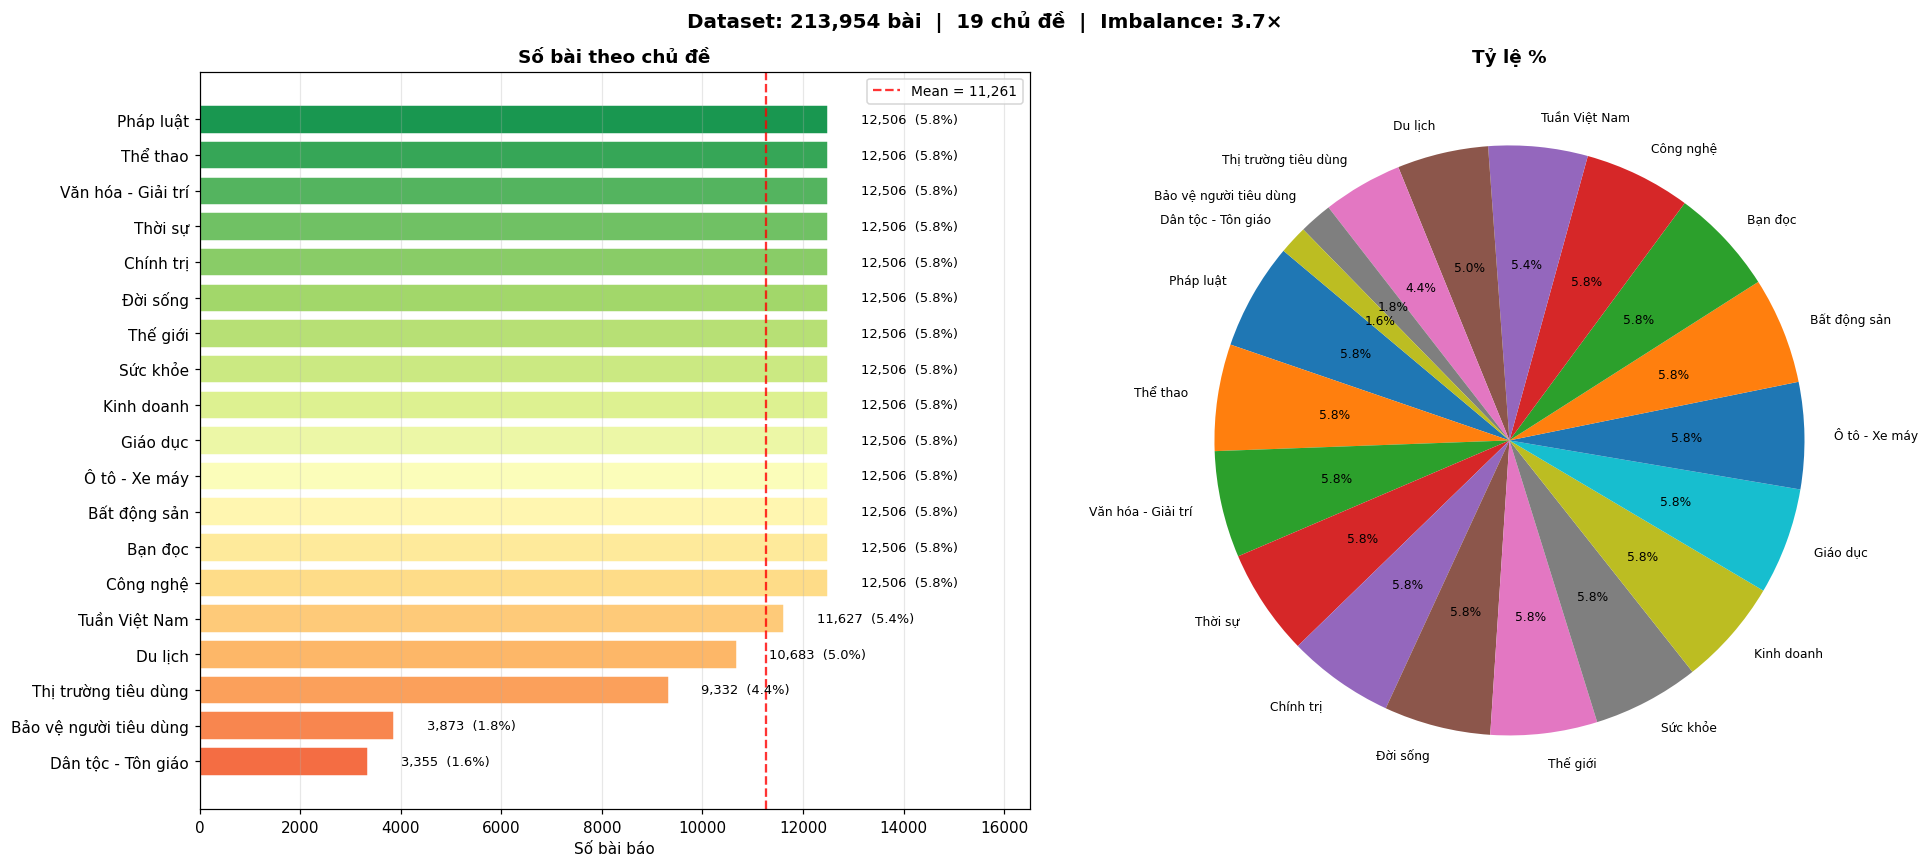

  Nhiều nhất : Công nghệ                             12,506
  Ít nhất    : Dân tộc - Tôn giáo                     3,355
  Imbalance  : 3.7×


In [5]:
# ── 2.1 Phân bố class ────────────────────────────────────────────────────────
_vc    = df_raw["label"].value_counts().sort_values(ascending=True)
_total = len(df_raw)
_cmap  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(_vc)))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

_bars = axes[0].barh(_vc.index, _vc.values, color=_cmap, edgecolor="white")
for bar, n in zip(_bars, _vc.values):
    axes[0].text(bar.get_width() + _total*0.003,
                 bar.get_y() + bar.get_height()/2,
                 f"{n:,}  ({n/_total*100:.1f}%)", va="center", fontsize=8.5)
axes[0].set_xlim(0, _vc.max()*1.32)
axes[0].axvline(_vc.mean(), color="red", ls="--", alpha=0.8, label=f"Mean = {_vc.mean():,.0f}")
axes[0].set_xlabel("Số bài báo"); axes[0].set_title("Số bài theo chủ đề", fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(axis="x", alpha=0.3)

axes[1].pie(_vc.values[::-1], labels=_vc.index[::-1],
            autopct="%1.1f%%", startangle=140, textprops={"fontsize":8})
axes[1].set_title("Tỷ lệ %", fontweight="bold")

_ir = _vc.max() / _vc.min()
fig.suptitle(f"Dataset: {_total:,} bài  |  {len(_vc)} chủ đề  |  Imbalance: {_ir:.1f}×",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "01_class_distribution.png")
print(f"  Nhiều nhất : {_vc.idxmax():<35} {_vc.max():>8,}")
print(f"  Ít nhất    : {_vc.idxmin():<35} {_vc.min():>8,}")
print(f"  Imbalance  : {_ir:.1f}×")

[03:25:10][  19.7s] >> Đã lưu → c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\02_text_length.png


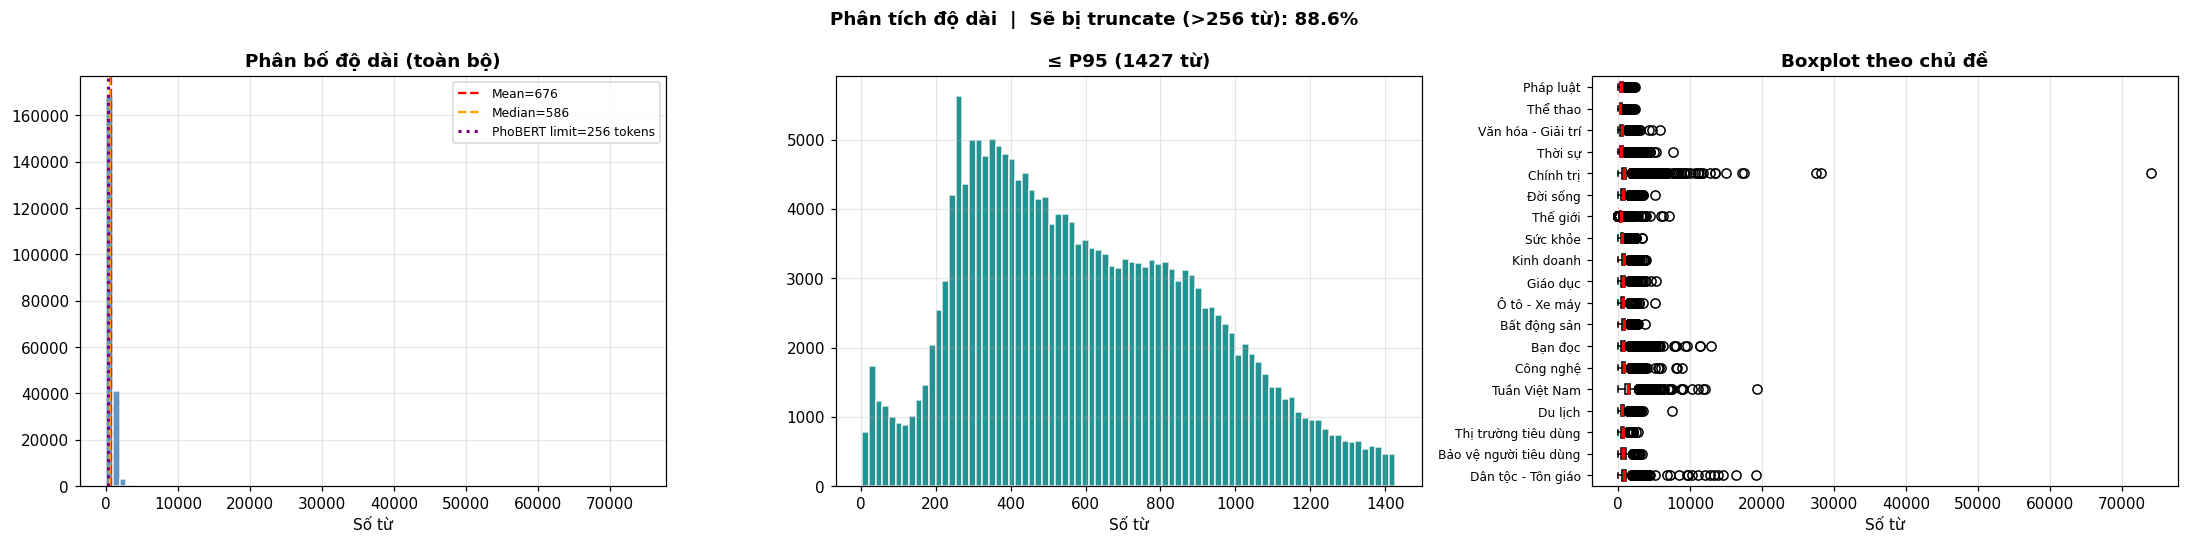

  Min     :      4.0 từ
  Median  :    586.0 từ
  Mean    :    675.5 từ
  P90     :  1,162.7 từ
  P95     :  1,427.0 từ
  Max     : 74,090.0 từ
  Trên 256 từ: 88.6% → dùng Head-Tail để tận dụng cả đầu lẫn cuối bài


In [6]:
# ── 2.2 Phân bố độ dài văn bản ──────────────────────────────────────────────
_lens = df_raw["text_len"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(_lens, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(_lens.mean(),   color="red",    ls="--", lw=1.5, label=f"Mean={_lens.mean():.0f}")
axes[0].axvline(_lens.median(), color="orange", ls="--", lw=1.5, label=f"Median={_lens.median():.0f}")
axes[0].axvline(256, color="purple", ls=":", lw=2, label="PhoBERT limit=256 tokens")
axes[0].set_xlabel("Số từ"); axes[0].set_title("Phân bố độ dài (toàn bộ)", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

_p95 = _lens.quantile(0.95)
axes[1].hist(_lens[_lens <= _p95], bins=80, color="teal", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Số từ"); axes[1].set_title(f"≤ P95 ({_p95:.0f} từ)", fontweight="bold")
axes[1].grid(alpha=0.3)

_cls_ord = list(df_raw["label"].value_counts().sort_values().index)
_lbc = [df_raw[df_raw["label"]==c]["text_len"].values for c in _cls_ord]
bp = axes[2].boxplot(_lbc, vert=False, patch_artist=True,
                     medianprops=dict(color="red", linewidth=2))
for patch, color in zip(bp["boxes"], plt.cm.Set3(np.linspace(0, 1, len(_cls_ord)))):
    patch.set_facecolor(color)
axes[2].set_yticks(range(1, len(_cls_ord)+1)); axes[2].set_yticklabels(_cls_ord, fontsize=8)
axes[2].set_xlabel("Số từ"); axes[2].set_title("Boxplot theo chủ đề", fontweight="bold")
axes[2].grid(axis="x", alpha=0.3)

_trunc_pct = (_lens > 256).mean()
fig.suptitle(f"Phân tích độ dài  |  Sẽ bị truncate (>256 từ): {_trunc_pct:.1%}",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_fig(fig, "02_text_length.png")

for _lbl, _v in [("Min",_lens.min()),("Median",_lens.median()),("Mean",_lens.mean()),
                  ("P90",_lens.quantile(.9)),("P95",_lens.quantile(.95)),("Max",_lens.max())]:
    print(f"  {_lbl:<8}: {_v:>8,.1f} từ")
print(f"  Trên 256 từ: {_trunc_pct:.1%} → dùng Head-Tail để tận dụng cả đầu lẫn cuối bài")

In [7]:
# ── 2.3 Bảng tổng hợp dataset ───────────────────────────────────────────────
_rows = []
for _cls in sorted(df_raw["label"].unique()):
    _sub = df_raw[df_raw["label"] == _cls]["text_len"]
    _rows.append({"Chủ đề": _cls, "Số bài": len(_sub),
                  "Tỷ lệ %": round(len(_sub)/len(df_raw)*100, 2),
                  "TB từ": round(_sub.mean(), 0), "Median từ": round(_sub.median(), 0),
                  "Max từ": int(_sub.max())})
_df_sum = pd.DataFrame(_rows).sort_values("Số bài", ascending=False).reset_index(drop=True)
_df_sum.index += 1
print("📊 BẢNG TỔNG HỢP DỮ LIỆU\n")
display(_df_sum.style
    .background_gradient(subset=["Số bài"], cmap="Blues")
    .background_gradient(subset=["TB từ"], cmap="Greens")
    .format({"Số bài":"{:,}", "Tỷ lệ %":"{:.2f}%", "TB từ":"{:.0f}", "Median từ":"{:.0f}"}))

📊 BẢNG TỔNG HỢP DỮ LIỆU



,Chủ đề,Số bài,Tỷ lệ %,TB từ,Median từ,Max từ
1,Bạn đọc,"12,506",5.85%,689,670,12921
2,Bất động sản,"12,506",5.85%,755,771,3750
3,Chính trị,"12,506",5.85%,957,822,74090
4,Đời sống,"12,506",5.85%,710,687,5131
5,Công nghệ,"12,506",5.85%,788,760,8906
6,Kinh doanh,"12,506",5.85%,779,759,3800
7,Giáo dục,"12,506",5.85%,665,609,5218
8,Pháp luật,"12,506",5.85%,469,391,2323
9,Sức khỏe,"12,506",5.85%,600,573,3350
10,Thể thao,"12,506",5.85%,374,314,2310


---
## 🔤 Section 3 — Tiền Xử Lý Văn Bản

**Lưu ý PhoBERT**: KHÔNG loại stopwords — BERT tự học contextual meaning.
Chỉ: lowercase → bỏ dấu câu → bỏ số → ViTokenizer (word segmentation).

- Cell 3.1: tokenize toàn bộ corpus, lưu `temp/processed_data.pkl` *(nặng ~20–40 phút; bỏ qua nếu cache đã có)*
- Cell 3.2: load dữ liệu đã xử lý *(luôn chạy)*

In [8]:
# ── 3.1 ViTokenize + Lưu cache ──────────────────────────────────────────────
if os.path.exists(PROCESSED_DATA_PATH):
    print(f"✅ Cache tồn tại: {PROCESSED_DATA_PATH}  — bỏ qua tokenization")
else:
    log("Bắt đầu tiền xử lý văn bản...")

    _df_proc = df_raw[["label"]].copy()
    _df_proc["full_text"] = (df_raw["title"]
                             + " " + df_raw["content"])
    _df_proc = _df_proc[_df_proc["full_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Văn bản hợp lệ: {len(_df_proc):,}", "OK")

    def _clean_one(text):
        '''ViTokenize không có stopwords (PhoBERT tự học context).'''
        from pyvi import ViTokenizer
        import re
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r"[^\w\s]", " ", text)
        text = re.sub(r"\d+",     " ", text)
        text = ViTokenizer.tokenize(text)
        return re.sub(r"\s+", " ", text).strip()

    from joblib import Parallel, delayed
    from multiprocessing import cpu_count
    log(f"Tokenize song song {len(_df_proc):,} bài | {cpu_count()} nhân CPU...")
    _df_proc["clean_text"] = Parallel(n_jobs=-1, backend="loky", verbose=1)(
        delayed(_clean_one)(t) for t in _df_proc["full_text"].tolist()
    )
    _df_proc = _df_proc[_df_proc["clean_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Sau tokenization: {len(_df_proc):,} bài", "OK")

    _classes  = sorted(_df_proc["label"].unique().tolist())
    _label2id = {l: i for i, l in enumerate(_classes)}
    _id2label = {i: l for l, i in _label2id.items()}
    _df_proc["label_id"] = _df_proc["label"].map(_label2id)

    with timer("Lưu processed_data.pkl"):
        with open(PROCESSED_DATA_PATH, "wb") as _f:
            pickle.dump({"df":_df_proc, "label2id":_label2id, "id2label":_id2label}, _f)
    log(f"Đã lưu ({os.path.getsize(PROCESSED_DATA_PATH)/1e6:.1f} MB)", "SAVE")

[03:25:11][  20.1s] i Bắt đầu tiền xử lý văn bản...
[03:25:11][  20.6s] OK Văn bản hợp lệ: 213,954
[03:25:11][  20.6s] i Tokenize song song 213,954 bài | 24 nhân CPU...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 185 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 3000 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 8600 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 15800 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done 24600 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 35000 tasks      | elapsed:   29.2s
[Parallel(n_jobs=-1)]: Done 47000 tasks      | elapsed:   40.4s
[Parallel(n_jobs=-1)]: Done 60600 tasks      | elapsed:   52.5s
[Parallel(n_jobs=-1)]: Done 75800 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 92600 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 111000 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 131000 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 152600 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 17

[03:28:41][ 230.1s] OK Sau tokenization: 213,954 bài


[Parallel(n_jobs=-1)]: Done 213954 out of 213954 | elapsed:  3.5min finished


[03:28:43][ 232.9s] OK Lưu processed_data.pkl — 2.8s
[03:28:43][ 232.9s] >> Đã lưu (1716.5 MB)


In [9]:
# ── 3.2 Load processed data (luôn chạy) ──────────────────────────────────────
with timer("Tải processed_data.pkl"):
    with open(PROCESSED_DATA_PATH, "rb") as f:
        _s = pickle.load(f)

df       = _s["df"]
label2id = _s["label2id"]
id2label = _s["id2label"]
classes  = sorted(df["label"].unique().tolist())
N_CLASSES = len(classes)

_vc3 = df["label"].value_counts()
print(f"✅ Processed data: {len(df):,} bài | {N_CLASSES} chủ đề\n")
print(f"   {'Chủ đề':<38}  {'Bài':>8}  {'%':>5}  TB tokens (ViTokenizer)")
print(f"   {'─'*62}")
for _cls in classes:
    _n   = _vc3.get(_cls, 0)
    _tl  = df[df["label"]==_cls]["clean_text"].str.split().str.len().mean()
    print(f"   {_cls:<38}  {_n:>8,}  {_n/len(df)*100:>4.1f}%  {_tl:>6.0f}")

[03:28:50][ 239.1s] OK Tải processed_data.pkl — 6.2s
✅ Processed data: 213,954 bài | 19 chủ đề

   Chủ đề                                       Bài      %  TB tokens (ViTokenizer)
   ──────────────────────────────────────────────────────────────
   Bạn đọc                                   12,506   5.8%     544
   Bảo vệ người tiêu dùng                     3,873   1.8%     588
   Bất động sản                              12,506   5.8%     551
   Chính trị                                 12,506   5.8%     644
   Công nghệ                                 12,506   5.8%     566
   Du lịch                                   10,683   5.0%     476
   Dân tộc - Tôn giáo                         3,355   1.6%     647
   Giáo dục                                  12,506   5.8%     487
   Kinh doanh                                12,506   5.8%     564
   Pháp luật                                 12,506   5.8%     352
   Sức khỏe                                  12,506   5.8%     444
   Thế giới      

---
## 🔢 Section 4 — Tokenize Head-Tail + Train/Test Split

**Chiến lược Head-Tail**: lấy 127 token đầu + 127 token cuối → tổng 256 (bao gồm [CLS] và [SEP]).
Hiệu quả khi bài báo dài — giữ được thông tin cả phần mở bài lẫn kết luận.

In [10]:
# ── 4.1 Định nghĩa Dataset + Helper classes ──────────────────────────────────
class HeadTailDataset(TorchDataset):
    '''Head+Tail: 127 token đầu + 127 token cuối (+ [CLS] + [SEP] = 256).'''
    def __init__(self, texts, labels, tokenizer, label2id):
        self.labels     = [label2id[l] for l in labels]
        self.input_ids  = []
        self.attn_masks = []
        half   = (MAX_LENGTH - 2) // 2
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        pad_id = tokenizer.pad_token_id

        for text in tqdm(texts.tolist(), desc="  HeadTail tokenize", ncols=80, leave=True):
            tokens = tokenizer.encode(text, add_special_tokens=False, truncation=False)
            if len(tokens) <= MAX_LENGTH - 2:
                enc  = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH)
                ids  = enc["input_ids"]
                attn = enc["attention_mask"]
            else:
                head  = tokens[:half]
                tail  = tokens[-half:]
                ids   = [cls_id] + head + tail + [sep_id]
                attn  = [1] * len(ids)
                pad_n = MAX_LENGTH - len(ids)
                ids  += [pad_id] * pad_n
                attn += [0]     * pad_n
            self.input_ids.append(ids)
            self.attn_masks.append(attn)

        # Chuyển list → stacked tensors ngay sau tokenize
        # __getitem__ chỉ cần tensor indexing — không tạo tensor mới mỗi sample
        self._to_tensors()

    def _to_tensors(self):
        '''Chuyển Python lists → stacked tensors. Gọi sau khi load cache cũ format.'''
        if isinstance(self.input_ids, list):
            self.input_ids  = torch.tensor(self.input_ids,  dtype=torch.long)
            self.attn_masks = torch.tensor(self.attn_masks, dtype=torch.long)
            self.labels     = torch.tensor(self.labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attn_masks[idx],
            "labels":         self.labels[idx],
        }


class WeightedTrainer(Trainer):
    '''Trainer với weighted cross-entropy để xử lý mất cân bằng class.'''
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss    = torch.nn.functional.cross_entropy(logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


class EpochCallback(TrainerCallback):
    '''Log chi tiết sau mỗi epoch + thời gian thực mỗi logging_steps.'''
    def __init__(self):
        self._train_start  = None
        self._epoch_start  = None
        self._total_steps  = None

    def on_train_begin(self, args, state, control, **kwargs):
        self._train_start = time.time()
        self._total_steps = state.max_steps
        log(f"Tổng steps: {self._total_steps:,}  |  {NUM_EPOCHS} epochs  |  "
            f"~{self._total_steps//NUM_EPOCHS:,} steps/epoch", "OK")

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._epoch_start = time.time()
        ep = int(state.epoch) + 1
        elapsed = time.time() - self._train_start if self._train_start else 0
        log(f"{'─'*50}")
        log(f"EPOCH {ep}/{NUM_EPOCHS} — bắt đầu  |  Đã chạy: {elapsed/60:.1f} phút")
        gpu_status()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or "loss" not in logs: return
        step    = state.global_step
        total   = self._total_steps or 1
        elapsed = time.time() - self._train_start if self._train_start else 0
        eta_sec = (elapsed / step * (total - step)) if step > 0 else 0
        spd     = logs.get("train_samples_per_second", 0)
        spd_str = f"  |  {spd:.0f} samples/s" if spd else ""
        log(f"step {step:>5}/{total}  [{step/total*100:4.1f}%]  "
            f"loss={logs['loss']:.4f}  lr={logs.get('learning_rate',0):.2e}  "
            f"elapsed={elapsed/60:.1f}m  ETA={eta_sec/60:.1f}m{spd_str}")

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        acc   = metrics.get("eval_accuracy",    0)
        f1_w  = metrics.get("eval_f1_weighted", 0)
        f1_m  = metrics.get("eval_f1_macro",    0)
        eloss = metrics.get("eval_loss",        0)
        ep_t  = time.time() - self._epoch_start if self._epoch_start else 0
        total_t = time.time() - self._train_start if self._train_start else 0
        log(f"EPOCH {state.epoch:.0f} DONE  |  Loss={eloss:.4f}  Acc={acc:.4f}  "
            f"F1-w={f1_w:.4f}  F1-m={f1_m:.4f}  "
            f"(epoch {ep_t/60:.1f}m  /  tổng {total_t/60:.1f}m)", "OK")

print("✅ Dataset classes và WeightedTrainer định nghĩa xong.")

✅ Dataset classes và WeightedTrainer định nghĩa xong.


In [11]:
# ── 4.2 Train/test split + Tạo HeadTail datasets ────────────────────────────
log("Train/test split (stratified)...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["label"]
)
log(f"Train: {len(X_train_raw):,}  |  Test: {len(X_test_raw):,}", "OK")

# Tải tokenizer PhoBERT
log(f"Tải tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Thống kê token length trên sample
_sample_text = df["clean_text"].sample(min(1000, len(df)), random_state=RANDOM_STATE).tolist()
_tlen = np.array([len(tokenizer.encode(t, truncation=False)) for t in
                  tqdm(_sample_text, desc="  Token length check", ncols=80)])
log(f"Token length — mean={_tlen.mean():.1f} | median={np.median(_tlen):.1f} | "
    f"max={_tlen.max()} | >256: {(_tlen>256).mean():.1%}", "OK")

# Tính class weights
log("Tính class weights (balanced + manual boost)...")
_cw_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=[label2id[l] for l in y_train],
)
for i, cls in enumerate(classes):
    _cw_vals[i] *= MANUAL_CLASS_BOOST.get(cls, 1.0)
class_weights = torch.tensor(_cw_vals, dtype=torch.float32)
print(f"\n   {'Chủ đề':<38}  {'Weight':>8}  {'Boost':>8}")
print(f"   {'─'*60}")
for i, cls in enumerate(classes):
    _boost = MANUAL_CLASS_BOOST.get(cls, 1.0)
    print(f"   {cls:<38}  {_cw_vals[i]:>8.4f}  {_boost:>8.2f}")

# ── Cache HeadTail datasets để tránh tokenize lại ────────────────────────────
_HT_TRAIN_CACHE = os.path.join(TEMP_DIR, "headtail_train.pkl")
_HT_TEST_CACHE  = os.path.join(TEMP_DIR, "headtail_test.pkl")

if os.path.exists(_HT_TRAIN_CACHE) and os.path.exists(_HT_TEST_CACHE):
    log("Tải HeadTail datasets từ cache...", "OK")
    with timer("Tải cache train"):
        with open(_HT_TRAIN_CACHE, "rb") as f:
            train_dataset = pickle.load(f)
    with timer("Tải cache test"):
        with open(_HT_TEST_CACHE, "rb") as f:
            test_dataset = pickle.load(f)
    # Cache cũ lưu lists → chuyển sang stacked tensors để __getitem__ nhanh hơn
    train_dataset._to_tensors()
    test_dataset._to_tensors()
    log("Đã tải HeadTail datasets từ cache", "OK")
else:
    log("Tạo HeadTail train dataset (lần đầu — sẽ cache lại)...")
    with timer("Train HeadTail"):
        train_dataset = HeadTailDataset(X_train_raw, y_train, tokenizer, label2id)
    with timer("Lưu train cache"):
        with open(_HT_TRAIN_CACHE, "wb") as f:
            pickle.dump(train_dataset, f)
    log(f"Đã lưu cache train ({os.path.getsize(_HT_TRAIN_CACHE)/1e6:.0f} MB)", "SAVE")

    log("Tạo HeadTail test dataset...")
    with timer("Test HeadTail"):
        test_dataset = HeadTailDataset(X_test_raw, y_test, tokenizer, label2id)
    with timer("Lưu test cache"):
        with open(_HT_TEST_CACHE, "wb") as f:
            pickle.dump(test_dataset, f)
    log(f"Đã lưu cache test ({os.path.getsize(_HT_TEST_CACHE)/1e6:.0f} MB)", "SAVE")

log(f"Train: {len(train_dataset):,} mẫu  |  Test: {len(test_dataset):,} mẫu", "OK")
log(f"Kích thước input_ids: {train_dataset.input_ids.shape}  dtype={train_dataset.input_ids.dtype}", "OK")
log(f"💡 Xóa cache khi không cần: {_HT_TRAIN_CACHE}", "INFO")
gpu_status()

[03:29:00][ 249.2s] i Train/test split (stratified)...
[03:29:00][ 249.3s] OK Train: 181,860  |  Test: 32,094
[03:29:00][ 249.3s] i Tải tokenizer: vinai/phobert-base-v2...


  Token length check: 100%|████████████████| 1000/1000 [00:02<00:00, 453.18it/s]

[03:29:06][ 255.6s] OK Token length — mean=577.6 | median=488.0 | max=4545 | >256: 84.3%
[03:29:06][ 255.6s] i Tính class weights (balanced + manual boost)...

   Chủ đề                                    Weight     Boost
   ────────────────────────────────────────────────────────────
   Bạn đọc                                   0.9004      1.00
   Bảo vệ người tiêu dùng                    2.9075      1.00
   Bất động sản                              0.9004      1.00
   Chính trị                                 0.9004      1.00
   Công nghệ                                 0.9004      1.00
   Du lịch                                   1.0540      1.00
   Dân tộc - Tôn giáo                        4.5307      1.35
   Giáo dục                                  0.9004      1.00
   Kinh doanh                                1.0355      1.15
   Pháp luật                                 0.9004      1.00
   Sức khỏe                                  0.9004      1.00
   Thế giới                     


  HeadTail tokenize: 100%|█████████████| 181860/181860 [05:44<00:00, 527.24it/s]


[03:34:55][ 604.4s] OK Train HeadTail — 348.8s
[03:34:56][ 605.3s] OK Lưu train cache — 0.9s
[03:34:56][ 605.3s] >> Đã lưu cache train (746 MB)
[03:34:56][ 605.3s] i Tạo HeadTail test dataset...


  HeadTail tokenize: 100%|███████████████| 32094/32094 [01:01<00:00, 523.86it/s]


[03:35:58][ 667.2s] OK Test HeadTail — 61.9s
[03:35:58][ 667.3s] OK Lưu test cache — 0.1s
[03:35:58][ 667.3s] >> Đã lưu cache test (132 MB)
[03:35:58][ 667.3s] OK Train: 181,860 mẫu  |  Test: 32,094 mẫu
[03:35:58][ 667.3s] OK Kích thước input_ids: torch.Size([181860, 256])  dtype=torch.int64
[03:35:58][ 667.3s] i 💡 Xóa cache khi không cần: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\temp\headtail_train.pkl
[03:35:58][ 667.3s] GPU VRAM: 0.0GB đã dùng / 0.0GB dự trữ / 12.0GB còn trống


---
## 🤖 Section 5 — Huấn Luyện Mô Hình

**PhoBERT Base v2** fine-tuning với Hugging Face Trainer.

| Tham số | Giá trị | Lý do |
|---------|---------|-------|
| `LR` | 1e-5 | Tránh catastrophic forgetting với pretrained model |
| `batch` | 32 × accum 2 = eff 64 | Phù hợp GPU 12GB, vẫn giữ effective batch 64 |
| `class_weight` | balanced | Dataset mất cân bằng |
| `BF16` | True | RTX A3000 (compute 8.6) hỗ trợ BF16 |
| `metric_for_best_model` | f1_macro | Ưu tiên các class ít mẫu hơn weighted F1 |

- Cell 5.1: training *(bỏ qua nếu `model/config.json` đã tồn tại)*
- Cell 5.2: load kết quả *(luôn chạy)*

In [12]:
# ── 5.1 Train PhoBERT + Lưu model ───────────────────────────────────────────
_MODEL_READY = os.path.exists(os.path.join(MODEL_DIR, "config.json"))
_CKPT_DIR    = os.path.join(TEMP_DIR, "checkpoints")

if _MODEL_READY:
    log(f"Model đã tồn tại: {MODEL_DIR}  — bỏ qua training", "OK")
else:
    torch.cuda.empty_cache()
    log(f"Tải mô hình PhoBERT: {MODEL_NAME}...")

    def make_compute_metrics():
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=1)
            return {
                "accuracy":    accuracy_score(labels, preds),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "f1_macro":    f1_score(labels, preds, average="macro"),
            }
        return compute_metrics

    model_train = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=N_CLASSES,
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(device)

    # Fix LayerNorm beta/gamma (PhoBERT checkpoint cũ)
    _sd = model_train.state_dict()
    _new_sd = {}
    for k, v in _sd.items():
        if k.endswith(".beta"):    _new_sd[k.replace(".beta",  ".bias")]   = v
        elif k.endswith(".gamma"): _new_sd[k.replace(".gamma", ".weight")] = v
        else:                      _new_sd[k] = v
    model_train.load_state_dict(_new_sd, strict=False)

    log(f"Tham số: {sum(p.numel() for p in model_train.parameters())/1e6:.1f}M", "OK")
    gpu_status()

    training_args = TrainingArguments(
        output_dir=_CKPT_DIR,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,       # 64
        per_device_eval_batch_size=EVAL_BATCH,        # 128
        gradient_accumulation_steps=GRAD_ACCUM,       # 1
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=WARMUP_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        bf16=BF16,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        # num_workers=0: bắt buộc trên Windows (Python 3.14 spawn multiprocessing
        # crash với large tensors trong worker). Dataset đã dùng stacked tensors
        # nên __getitem__ rất nhanh — bottleneck là GPU chứ không phải CPU.
        dataloader_num_workers=0,
        dataloader_pin_memory=True,
        gradient_checkpointing=False,                 # OFF — đủ cho base-v2 trên 12GB
        optim="adamw_torch_fused",                    # ~15% nhanh hơn optimizer step
        torch_compile=False,                          # Python 3.14+ chưa hỗ trợ
    )

    trainer = WeightedTrainer(
        model=model_train,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=make_compute_metrics(),
        class_weights=class_weights,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3),
            EpochCallback(),
        ],
    )

    log("🔥 Bắt đầu fine-tuning PhoBERT...")
    _t_start = time.time()
    trainer.train()
    _train_time = time.time() - _t_start
    log(f"Training xong — {_train_time:.0f}s ({_train_time/60:.1f} phút)", "OK")
    gpu_status()

    # Lưu model + tokenizer
    trainer.save_model(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)
    log(f"Đã lưu mô hình: {MODEL_DIR}", "SAVE")

    # Lưu training history
    with open(TRAIN_HISTORY_PATH, "wb") as f:
        pickle.dump({"log_history": trainer.state.log_history,
                     "train_time_sec": _train_time}, f)
    log(f"Đã lưu lịch sử huấn luyện: {TRAIN_HISTORY_PATH}", "SAVE")

    # Dọn checkpoints
    if os.path.exists(_CKPT_DIR):
        shutil.rmtree(_CKPT_DIR)
    del model_train, trainer
    torch.cuda.empty_cache()
    log("VRAM đã giải phóng", "OK")

[03:35:58][ 667.3s] i Tải mô hình PhoBERT: vinai/phobert-base-v2...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 22358.42it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[03:36:18][ 687.7s] OK Tham số: 135.0M
[03:36:18][ 687.7s] GPU VRAM: 0.5GB đã dùng / 0.6GB dự trữ / 11.4GB còn trống
[03:36:19][ 687.9s] i 🔥 Bắt đầu fine-tuning PhoBERT...
[03:36:19][ 688.1s] OK Tổng steps: 19,894  |  7 epochs  |  ~2,842 steps/epoch
[03:36:19][ 688.1s] i ──────────────────────────────────────────────────
[03:36:19][ 688.1s] i EPOCH 1/7 — bắt đầu  |  Đã chạy: 0.0 phút
[03:36:19][ 688.1s] GPU VRAM: 0.5GB đã dùng / 0.6GB dự trữ / 11.4GB còn trống


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.995551,0.451632,0.872624,0.873463,0.861166
2,0.680932,0.370832,0.891350,0.891108,0.881979
3,0.576864,0.354880,0.896928,0.897544,0.887034
4,0.462591,0.356141,0.901975,0.902458,0.894497
5,0.383653,0.346231,0.902723,0.902883,0.894129
6,0.295406,0.351089,0.906898,0.907010,0.899284
7,0.291230,0.358784,0.906992,0.907127,0.899443


[03:37:31][ 760.6s] i step   100/19894  [ 0.5%]  loss=5.7939  lr=4.95e-06  elapsed=1.2m  ETA=239.1m
[03:38:44][ 833.6s] i step   200/19894  [ 1.0%]  loss=5.0595  lr=9.95e-06  elapsed=2.4m  ETA=238.8m
[03:39:58][ 907.2s] i step   300/19894  [ 1.5%]  loss=3.9293  lr=9.95e-06  elapsed=3.7m  ETA=238.5m
[03:41:12][ 981.2s] i step   400/19894  [ 2.0%]  loss=3.2197  lr=9.90e-06  elapsed=4.9m  ETA=238.1m
[03:42:26][1055.5s] i step   500/19894  [ 2.5%]  loss=2.8016  lr=9.85e-06  elapsed=6.1m  ETA=237.5m
[03:43:41][1130.0s] i step   600/19894  [ 3.0%]  loss=2.4566  lr=9.80e-06  elapsed=7.4m  ETA=236.8m
[03:44:55][1204.4s] i step   700/19894  [ 3.5%]  loss=2.1957  lr=9.75e-06  elapsed=8.6m  ETA=236.0m
[03:46:09][1278.8s] i step   800/19894  [ 4.0%]  loss=2.0140  lr=9.70e-06  elapsed=9.8m  ETA=235.0m
[03:47:24][1353.1s] i step   900/19894  [ 4.5%]  loss=1.8821  lr=9.65e-06  elapsed=11.1m  ETA=233.9m
[03:48:38][1427.4s] i step  1000/19894  [ 5.0%]  loss=1.7522  lr=9.59e-06  elapsed=12.3m  ETA=232.8

...

[07:17:56][13985.2s] i ──────────────────────────────────────────────────
[07:17:56][13985.2s] i EPOCH 7/7 — bắt đầu  |  Đã chạy: 221.6 phút
[07:17:56][13985.2s] GPU VRAM: 1.5GB đã dùng / 5.7GB dự trữ / 6.3GB còn trống
[07:18:31][14020.8s] i step 17100/19894  [86.0%]  loss=0.2748  lr=1.42e-06  elapsed=222.2m  ETA=36.3m
[07:19:46][14095.0s] i step 17200/19894  [86.5%]  loss=0.2946  lr=1.37e-06  elapsed=223.4m  ETA=35.0m
[07:21:00][14169.3s] i step 17300/19894  [87.0%]  loss=0.2872  lr=1.32e-06  elapsed=224.7m  ETA=33.7m
[07:22:14][14243.7s] i step 17400/19894  [87.5%]  loss=0.3154  lr=1.27e-06  elapsed=225.9m  ETA=32.4m
[07:23:29][14318.1s] i step 17500/19894  [88.0%]  loss=0.2733  lr=1.22e-06  elapsed=227.2m  ETA=31.1m
[07:24:43][14392.5s] i step 17600/19894  [88.5%]  loss=0.2695  lr=1.17e-06  elapsed=228.4m  ETA=29.8m
[07:25:57][14466.9s] i step 17700/19894  [89.0%]  loss=0.2714  lr=1.11e-06  elapsed=229.6m  ETA=28.5m
[07:27:12][14541.3s] i step 17800/19894  [89.5%]  loss=0.3012  lr=1

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

[07:54:50][16199.1s] OK Training xong — 15511s (258.5 phút)
[07:54:50][16199.1s] GPU VRAM: 1.5GB đã dùng / 5.7GB dự trữ / 6.3GB còn trống


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.16it/s]

[07:54:50][16199.6s] >> Đã lưu mô hình: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model
[07:54:50][16199.6s] >> Đã lưu lịch sử huấn luyện: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model\train_history.pkl
[07:54:50][16199.8s] OK VRAM đã giải phóng


In [13]:
# ── 5.2 Load model + Predict test set (luôn chạy) ───────────────────────────
log(f"Tải mô hình từ {MODEL_DIR}...")
model_eval = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=N_CLASSES,
    id2label=id2label,
    label2id=label2id,
).to(device)
model_eval.eval()

def make_compute_metrics():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {"accuracy":    accuracy_score(labels, preds),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "f1_macro":    f1_score(labels, preds, average="macro")}
    return compute_metrics

_eval_args = TrainingArguments(
    output_dir=TEMP_DIR, per_device_eval_batch_size=EVAL_BATCH,
    bf16=BF16, report_to="none",
    dataloader_num_workers=0,       # Windows: spawn multiprocessing crash với num_workers>0
    dataloader_pin_memory=True,
)
_eval_trainer = Trainer(
    model=model_eval, args=_eval_args,
    eval_dataset=test_dataset, compute_metrics=make_compute_metrics(),
)

log("Predict test set...")
with timer("Inference"):
    _raw = _eval_trainer.predict(test_dataset)

y_pred_ids  = np.argmax(_raw.predictions, axis=1).tolist()
y_true_ids  = [label2id[l] for l in y_test]
raw_logits  = _raw.predictions

model_acc   = accuracy_score(y_true_ids, y_pred_ids)
model_f1w   = f1_score(y_true_ids, y_pred_ids, average="weighted")
model_f1m   = f1_score(y_true_ids, y_pred_ids, average="macro")
f1_per_class= dict(zip(classes, f1_score(y_true_ids, y_pred_ids,
                                          labels=list(range(N_CLASSES)), average=None)))

# Load training history nếu có
log_history = []
train_time_sec = 0
if os.path.exists(TRAIN_HISTORY_PATH):
    with open(TRAIN_HISTORY_PATH, "rb") as f:
        _hist = pickle.load(f)
    log_history    = _hist.get("log_history", [])
    train_time_sec = _hist.get("train_time_sec", 0)

print(f"\n{'='*55}")
print(f"  PhoBERT Base v2 — Head-Tail")
print(f"  {'─'*52}")
print(f"  Accuracy   : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
if train_time_sec:
    print(f"  Train time : {train_time_sec/60:.1f} phút")
print(f"{'='*55}")
gpu_status()

[07:54:50][16199.8s] i Tải mô hình từ c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8851.72it/s]


[07:54:51][16200.2s] i Predict test set...


[07:56:34][16303.6s] OK Inference — 103.4s

  PhoBERT Base v2 — Head-Tail
  ────────────────────────────────────────────────────
  Accuracy   : 0.9070  (90.70%)
  F1-weighted: 0.9071
  F1-macro   : 0.8994
  Train time : 258.5 phút
[07:56:34][16303.6s] GPU VRAM: 1.0GB đã dùng / 1.7GB dự trữ / 10.3GB còn trống


---
## 📈 Section 6 — Đánh Giá Mô Hình

Classification report, confusion matrix, F1 từng chủ đề, training curves.

In [14]:
# ── 6.1 Classification Report ────────────────────────────────────────────────
_report_str = classification_report(y_true_ids, y_pred_ids, target_names=classes, digits=4)

print(f"{'='*65}")
print(f"  CLASSIFICATION REPORT — PhoBERT Base v2 Head-Tail")
print(f"  {'─'*62}")
print(f"  Accuracy   : {model_acc:.4f}")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
print(f"{'='*65}")
print(_report_str)

_rp = os.path.join(RESULTS_DIR, "classification_report.txt")
with open(_rp, "w", encoding="utf-8") as f:
    f.write(f"PhoBERT Base v2 — Head-Tail\n")
    f.write(f"Accuracy:    {model_acc:.4f}\n")
    f.write(f"F1-weighted: {model_f1w:.4f}\n")
    f.write(f"F1-macro:    {model_f1m:.4f}\n\n")
    f.write(_report_str)
log(f"Đã lưu: {_rp}", "SAVE")

  CLASSIFICATION REPORT — PhoBERT Base v2 Head-Tail
  ──────────────────────────────────────────────────────────────
  Accuracy   : 0.9070
  F1-weighted: 0.9071
  F1-macro   : 0.8994
                        precision    recall  f1-score   support

               Bạn đọc     0.9553    0.9344    0.9448      1876
Bảo vệ người tiêu dùng     0.8957    0.8571    0.8760       581
          Bất động sản     0.9084    0.9200    0.9142      1876
             Chính trị     0.8851    0.8993    0.8921      1876
             Công nghệ     0.9100    0.9104    0.9102      1876
               Du lịch     0.8701    0.9070    0.8881      1602
    Dân tộc - Tôn giáo     0.6963    0.8569    0.7683       503
              Giáo dục     0.9262    0.9360    0.9311      1876
            Kinh doanh     0.8277    0.8193    0.8235      1876
             Pháp luật     0.9047    0.9163    0.9105      1876
              Sức khỏe     0.9486    0.9339    0.9412      1876
              Thế giới     0.9597    0.9776    0

[07:56:35][16304.7s] >> Đã lưu → c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\03_confusion_matrix.png


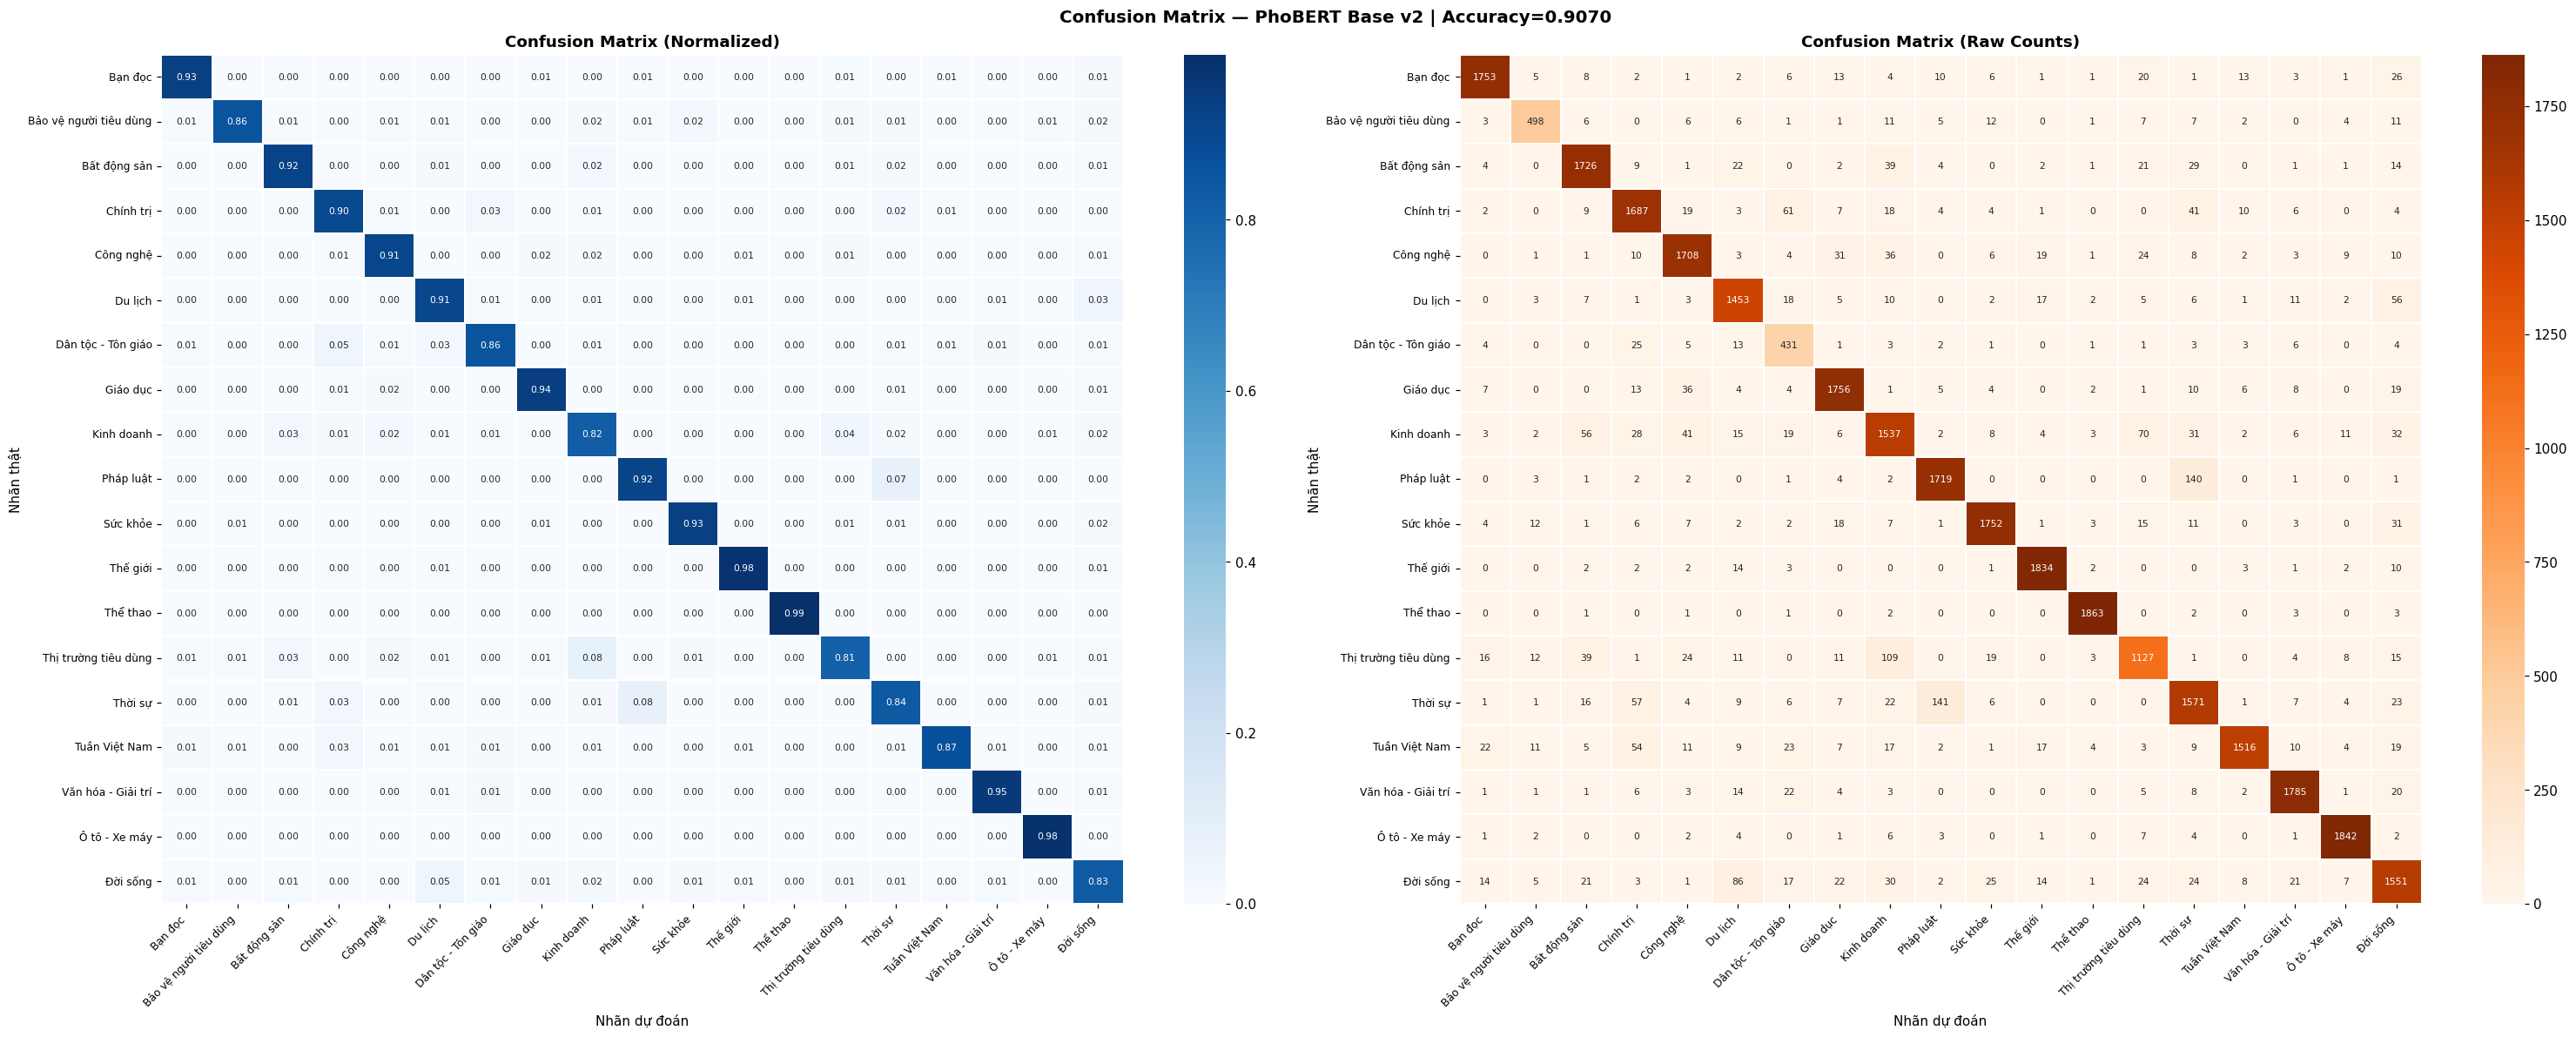

In [15]:
# ── 6.2 Confusion Matrix ─────────────────────────────────────────────────────
_cm   = confusion_matrix(y_true_ids, y_pred_ids, labels=list(range(N_CLASSES)))
_cmn  = _cm.astype(float) / _cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(28, 11))
for ax, data, fmt, cmap, title in [
    (axes[0], _cmn, ".2f", "Blues",   "Normalized"),
    (axes[1], _cm,  "d",   "Oranges", "Raw Counts"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.3, linecolor="white", ax=ax, annot_kws={"size":7})
    ax.set_xlabel("Nhãn dự đoán", fontsize=10)
    ax.set_ylabel("Nhãn thật",    fontsize=10)
    ax.set_title(f"Confusion Matrix ({title})", fontsize=12, fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

fig.suptitle(f"Confusion Matrix — PhoBERT Base v2 | Accuracy={model_acc:.4f}",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "03_confusion_matrix.png")

[07:56:36][16305.4s] >> Đã lưu → c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\04_f1_per_class.png


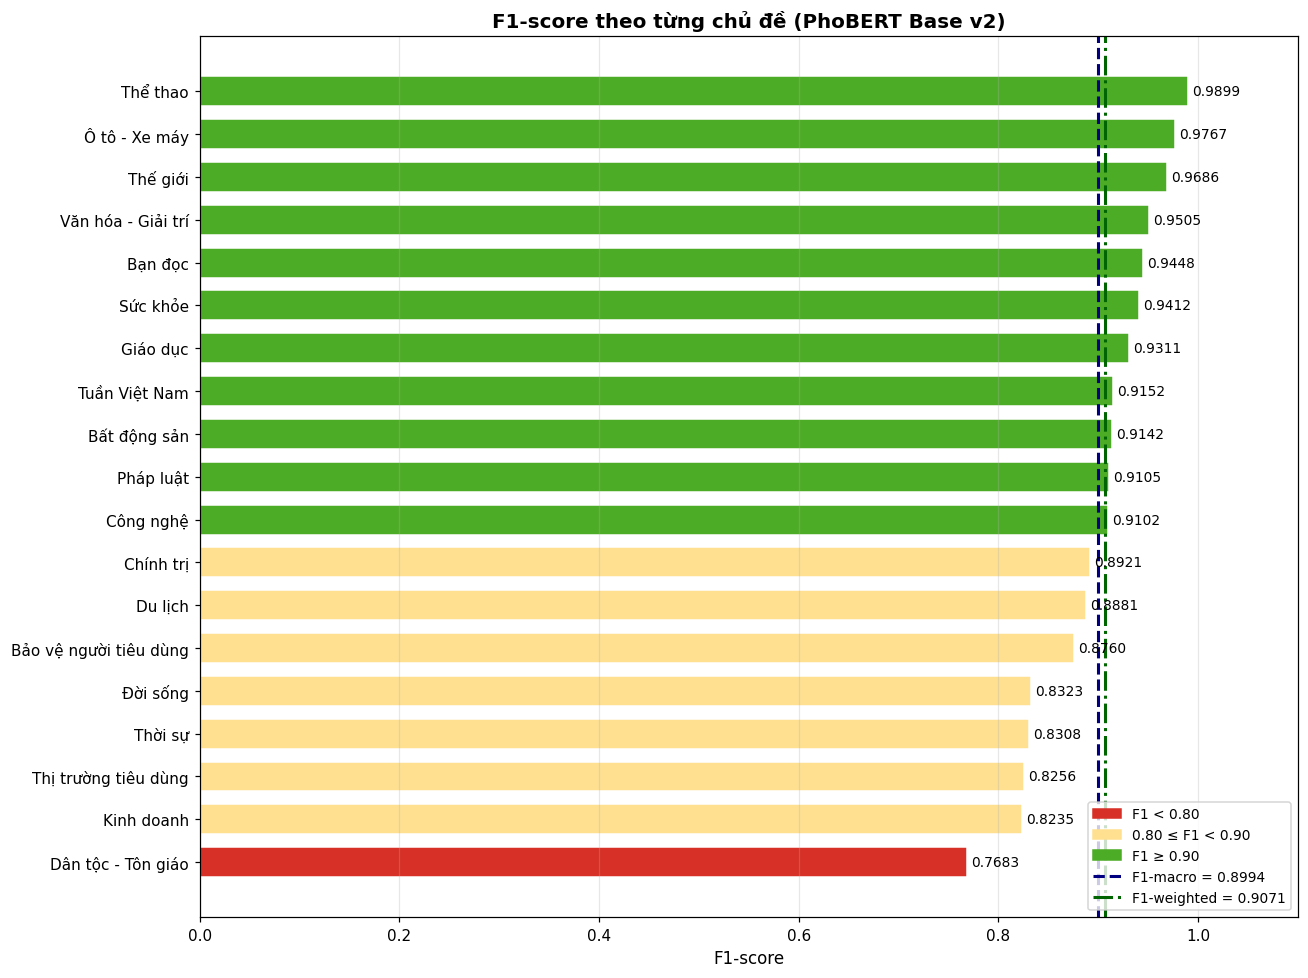

In [16]:
# ── 6.3 F1-score theo từng chủ đề ────────────────────────────────────────────
_f1_items = sorted(f1_per_class.items(), key=lambda x: x[1])
_cls_names = [x[0] for x in _f1_items]
_cls_f1    = [x[1] for x in _f1_items]
_colors    = ["#d73027" if v < 0.80 else "#fee090" if v < 0.90 else "#4dac26" for v in _cls_f1]

fig, ax = plt.subplots(figsize=(12, 9))
_bars = ax.barh(_cls_names, _cls_f1, color=_colors, edgecolor="white", height=0.7)
for bar, v in zip(_bars, _cls_f1):
    ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=9)

ax.axvline(model_f1m, color="navy",      ls="--", lw=2, label=f"F1-macro = {model_f1m:.4f}")
ax.axvline(model_f1w, color="darkgreen", ls="-.", lw=2, label=f"F1-weighted = {model_f1w:.4f}")
ax.set_xlim(0, 1.10); ax.set_xlabel("F1-score", fontsize=11)
ax.set_title("F1-score theo từng chủ đề (PhoBERT Base v2)", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.legend(handles=[
    Patch(color="#d73027", label="F1 < 0.80"),
    Patch(color="#fee090", label="0.80 ≤ F1 < 0.90"),
    Patch(color="#4dac26", label="F1 ≥ 0.90"),
    plt.Line2D([0],[0], color="navy",      ls="--", lw=2, label=f"F1-macro = {model_f1m:.4f}"),
    plt.Line2D([0],[0], color="darkgreen", ls="-.", lw=2, label=f"F1-weighted = {model_f1w:.4f}"),
], fontsize=9, loc="lower right")
fig.tight_layout()
save_fig(fig, "04_f1_per_class.png")

[07:56:36][16305.8s] >> Đã lưu → c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\05_training_curves.png


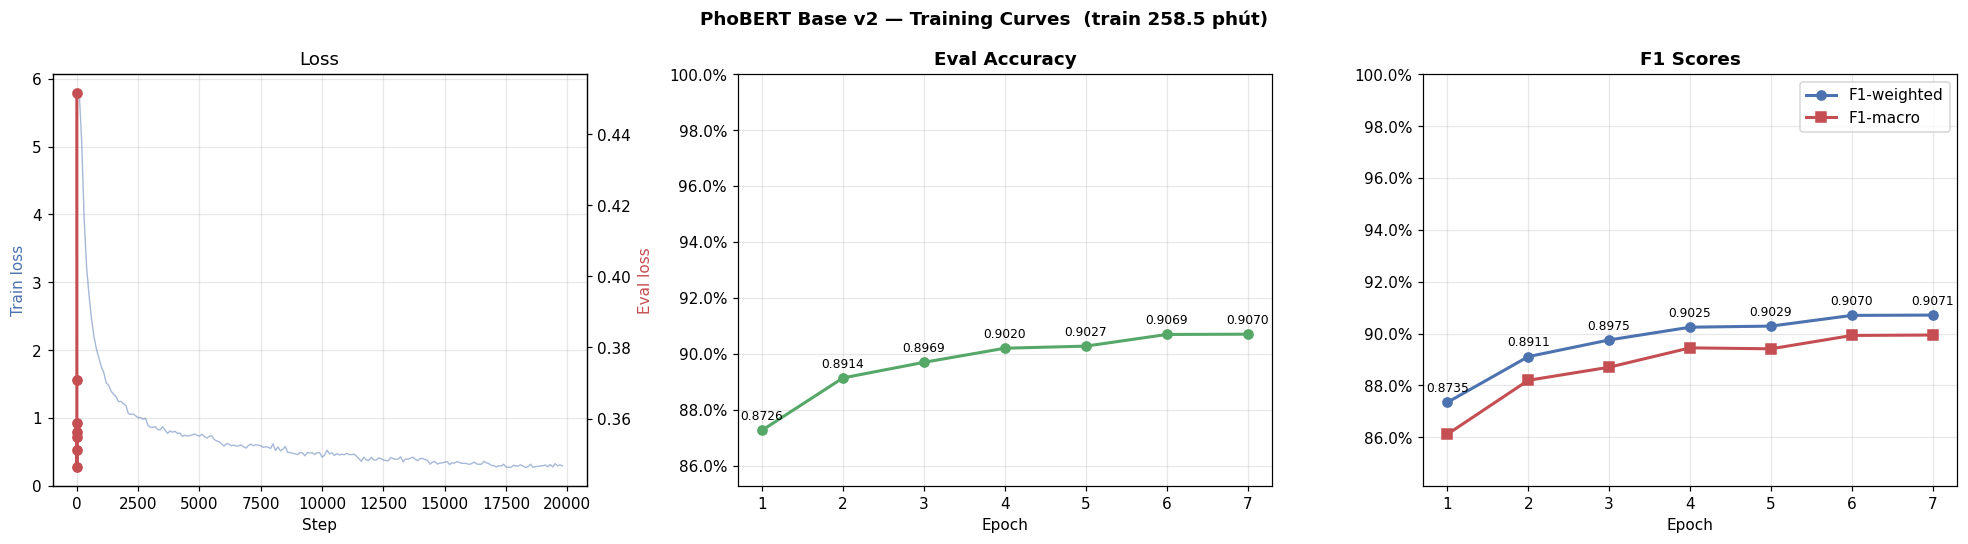

In [17]:
# ── 6.4 Training Curves ──────────────────────────────────────────────────────
if not log_history:
    print("⚠️  Không có log_history (model load từ cache). Bỏ qua training curves.")
else:
    _train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    _eval_logs  = [x for x in log_history if "eval_loss" in x]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot([x["step"] for x in _train_logs], [x["loss"] for x in _train_logs],
                 alpha=0.5, color="#4C72B0", lw=0.9, label="Train loss")
    _ax2 = axes[0].twinx()
    _ax2.plot([x["epoch"] for x in _eval_logs], [x["eval_loss"] for x in _eval_logs],
              marker="o", color="#C44E52", lw=2, label="Eval loss")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Train loss", color="#4C72B0")
    _ax2.set_ylabel("Eval loss", color="#C44E52"); axes[0].set_title("Loss"); axes[0].grid(alpha=0.3)

    # Accuracy
    _ep = [x["epoch"] for x in _eval_logs]
    _ac = [x.get("eval_accuracy",0) for x in _eval_logs]
    axes[1].plot(_ep, _ac, marker="o", color="#55A868", lw=2)
    for x, y in zip(_ep, _ac):
        axes[1].annotate(f"{y:.4f}", (x,y), textcoords="offset points", xytext=(0,7),
                         ha="center", fontsize=8)
    axes[1].set_xlabel("Epoch"); axes[1].set_title("Eval Accuracy", fontweight="bold")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[1].set_ylim(max(0.7, min(_ac)-0.02), 1.0); axes[1].grid(alpha=0.3)

    # F1
    _f1w = [x.get("eval_f1_weighted",0) for x in _eval_logs]
    _f1m = [x.get("eval_f1_macro",0)    for x in _eval_logs]
    axes[2].plot(_ep, _f1w, marker="o", label="F1-weighted", color="#4C72B0", lw=2)
    axes[2].plot(_ep, _f1m, marker="s", label="F1-macro",    color="#C44E52", lw=2)
    for x, y in zip(_ep, _f1w):
        axes[2].annotate(f"{y:.4f}", (x,y), textcoords="offset points", xytext=(0,7),
                         ha="center", fontsize=8)
    axes[2].set_xlabel("Epoch"); axes[2].set_title("F1 Scores", fontweight="bold")
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[2].set_ylim(max(0.7, min(_f1w+_f1m)-0.02), 1.0); axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle(f"PhoBERT Base v2 — Training Curves  (train {train_time_sec/60:.1f} phút)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "05_training_curves.png")

In [25]:
# ── 6.5 Tóm tắt kết quả ─────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  📋 KẾT QUẢ — PhoBERT Base v2 Head-Tail")
print(f"{'='*60}")
print(f"\n  [CẤU HÌNH MÔ HÌNH]")
print(f"    Model        : {MODEL_NAME}")
print(f"    Strategy     : Head-Tail (127 + 127 tokens)")
print(f"    MAX_LENGTH   : {MAX_LENGTH}")
print(f"    Batch (eff)  : {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print(f"    LR           : {LR}  |  Epochs: {NUM_EPOCHS}  |  BF16: {BF16}")
print(f"    class_weight : balanced")
print(f"\n  [DỮ LIỆU]")
print(f"    Số chủ đề    : {N_CLASSES}")
print(f"    Train        : {len(y_train):,} bài  ({(1-TEST_SIZE)*100:.0f}%)")
print(f"    Test         : {len(y_test):,} bài   ({TEST_SIZE*100:.0f}%)")
if train_time_sec:
    print(f"    Train time   : {train_time_sec/60:.1f} phút  ({train_time_sec/3600:.2f} giờ)")
print(f"\n  [HIỆU NĂNG TRÊN TẬP TEST]")
print(f"    Accuracy     : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"    F1-weighted  : {model_f1w:.4f}")
print(f"    F1-macro     : {model_f1m:.4f}")
print(f"\n  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1])[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")
print(f"\n  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")

_cm2      = confusion_matrix(y_true_ids, y_pred_ids, labels=list(range(N_CLASSES)))
_confused = sorted(
    [(_cm2[i,j], classes[i], classes[j])
     for i in range(N_CLASSES) for j in range(N_CLASSES) if i!=j and _cm2[i,j]>0],
    reverse=True
)
print(f"\n  [TOP 5 CẶP CHỦ ĐỀ BỊ NHẦM NHIỀU NHẤT]")
for _cnt, _tr, _pr in _confused[:5]:
    print(f"    {_tr:<28} → {_pr:<28}  {_cnt:>4} lần")

print(f"\n  [FILE KẾT QUẢ ĐÃ LƯU]")
for _f in sorted(os.listdir(RESULTS_DIR)):
    _fp = os.path.join(RESULTS_DIR, _f)
    print(f"    {_f:<38}  ({os.path.getsize(_fp)/1024:.1f} KB)")
print(f"\n{'='*60}")


  📋 KẾT QUẢ — PhoBERT Base v2 Head-Tail

  [CẤU HÌNH MÔ HÌNH]
    Model        : vinai/phobert-base-v2
    Strategy     : Head-Tail (127 + 127 tokens)
    MAX_LENGTH   : 256
    Batch (eff)  : 32 × 2 = 64
    LR           : 1e-05  |  Epochs: 7  |  BF16: True
    class_weight : balanced

  [DỮ LIỆU]
    Số chủ đề    : 19
    Train        : 181,860 bài  (85%)
    Test         : 32,094 bài   (15%)
    Train time   : 258.5 phút  (4.31 giờ)

  [HIỆU NĂNG TRÊN TẬP TEST]
    Accuracy     : 0.9070  (90.70%)
    F1-weighted  : 0.9071
    F1-macro     : 0.8994

  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]
    Dân tộc - Tôn giáo                      F1 = 0.7683
    Kinh doanh                              F1 = 0.8235
    Thị trường tiêu dùng                    F1 = 0.8256
    Thời sự                                 F1 = 0.8308
    Đời sống                                F1 = 0.8323

  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]
    Thể thao                                F1 = 0.9899
    Ô tô - Xe máy                        

---
## 📦 Section 7 — Export Model Config

Lưu `label_config.json` vào `model/` như metadata đi kèm model để inference có thể dùng lại cấu hình nhãn và tiền xử lý.
Model + tokenizer đã được lưu tự động bởi Trainer ở Section 5.

In [19]:
# ── 7.1 Export label config ──────────────────────────────────────────────────
_label_config = {
    "model_name":  MODEL_NAME,
    "strategy":    "head_tail",
    "max_length":  MAX_LENGTH,
    "n_classes":   N_CLASSES,
    "classes":     classes,
    "label2id":    label2id,
    "id2label":    {str(k): v for k, v in id2label.items()},
    "preprocessing": {
        "title_weight":  1,
        "lowercase":     True,
        "remove_punct":  True,
        "remove_digits": True,
        "tokenizer":     "pyvi.ViTokenizer",
        "stopwords":     False,
    },
}
with open(LABEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(_label_config, f, ensure_ascii=False, indent=2)
log(f"Đã lưu: {LABEL_CONFIG_PATH}", "SAVE")

# ── Smoke test: load model và predict 3 bài ──────────────────────────────────
print(f"\n  [SMOKE TEST — 3 bài ngẫu nhiên]\n")

def _infer(title, content):
    from pyvi import ViTokenizer
    text  = (str(title) + " " + str(content)).lower()
    text  = re.sub(r"[^\w\s]", " ", text)
    text  = re.sub(r"\d+",     " ", text)
    text  = ViTokenizer.tokenize(text)
    text  = re.sub(r"\s+",     " ", text).strip()
    half  = (MAX_LENGTH - 2) // 2
    enc_full = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if len(enc_full) <= MAX_LENGTH - 2:
        enc = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH,
                        return_tensors="pt")
    else:
        head = enc_full[:half]; tail = enc_full[-half:]
        ids  = [tokenizer.cls_token_id] + head + tail + [tokenizer.sep_token_id]
        ids += [tokenizer.pad_token_id] * (MAX_LENGTH - len(ids))
        enc  = {"input_ids": torch.tensor([ids]),
                "attention_mask": torch.tensor([[1]*min(len(enc_full)+2, MAX_LENGTH)
                                                 + [0]*(MAX_LENGTH - min(len(enc_full)+2, MAX_LENGTH))])}
    with torch.no_grad():
        logits = model_eval(**{k: v.to(device) for k,v in enc.items()}).logits
    return classes[logits.argmax(-1).item()]

_rng = np.random.default_rng(42)
_ok  = 0
for _i in _rng.choice(len(df_raw), size=3, replace=False):
    _row  = df_raw.iloc[_i]
    _pred = _infer(_row["title"], _row["content"])
    _ok  += int(_pred == _row["label"])
    _mark = "✅" if _pred == _row["label"] else "❌"
    print(f"  {_mark}  Thật: {_row['label']:<32}  Dự đoán: {_pred}")
print(f"\n  Smoke test: {_ok}/3 đúng")

print(f"\n  [FILE ĐÃ LƯU TRONG model/]")
for _f in sorted(os.listdir(MODEL_DIR)):
    _fp = os.path.join(MODEL_DIR, _f)
    if os.path.isfile(_fp):
        print(f"    {_f:<35}  ({os.path.getsize(_fp)/1024:.1f} KB)")

[07:56:37][16306.0s] >> Đã lưu: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model\label_config.json

  [SMOKE TEST — 3 bài ngẫu nhiên]

  ✅  Thật: Sức khỏe                          Dự đoán: Sức khỏe
  ✅  Thật: Bất động sản                      Dự đoán: Bất động sản
  ✅  Thật: Thể thao                          Dự đoán: Thể thao

  Smoke test: 3/3 đúng

  [FILE ĐÃ LƯU TRONG model/]
    added_tokens.json                    (0.0 KB)
    bpe.codes                            (1108.6 KB)
    config.json                          (2.2 KB)
    label_config.json                    (1.9 KB)
    model.safetensors                    (527417.6 KB)
    tokenizer_config.json                (1.2 KB)
    train_history.pkl                    (11.9 KB)
    training_args.bin                    (5.1 KB)
    vocab.txt                            (874.3 KB)


---
## 🎯 Section 8 — Threshold Calibration

Thay vì `argmax(logits)`, tìm ngưỡng tối ưu **riêng cho từng class** để cải thiện F1 các class yếu.

**Cơ chế:** `predict = argmax(probs / thresholds)` — class nào có ngưỡng cao hơn sẽ khó được chọn hơn (giảm over-prediction), class nào có ngưỡng thấp hơn sẽ dễ được chọn hơn (giảm under-prediction).

> **Lưu ý:** Thresholds được tìm trên test set — hơi optimistic. Trong production nên dùng validation set riêng.

In [20]:
# ── 8.0 Temperature Scaling — calibrate overconfidence cua softmax ────────────────
# Softmax raw cua neural network thuong overconfident (99.9% khi sai).
# Temperature Scaling: probs = softmax(logits / T), T > 1 lam mem phan phoi.
# Tim T toi uu bang cach minimize NLL tren tap test.
from scipy.optimize import minimize_scalar
from scipy.special import softmax as sp_softmax
import numpy as _np

_logits = raw_logits          # shape [N, 19]
_labels = np.array(y_true_ids)  # shape [N]

def _nll(T):
    """Negative log-likelihood sau khi scale logits voi nhiet do T."""
    scaled = _logits / max(T, 1e-3)
    p = sp_softmax(scaled, axis=1)
    true_p = p[np.arange(len(_labels)), _labels]
    return -np.mean(np.log(true_p + 1e-10))

_result = minimize_scalar(_nll, bounds=(0.5, 5.0), method="bounded")
T_OPTIMAL = float(_result.x)

# So sanh NLL truoc / sau
_nll_before = _nll(1.0)
_nll_after  = _nll(T_OPTIMAL)

# ECE truoc / sau (Expected Calibration Error, 15 bins)
def _ece(logits, labels, T=1.0, n_bins=15):
    p = sp_softmax(logits / T, axis=1)
    conf = p.max(axis=1)
    pred = p.argmax(axis=1)
    acc_bins, conf_bins, counts = [], [], []
    for b in range(n_bins):
        lo, hi = b/n_bins, (b+1)/n_bins
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() == 0: continue
        acc_bins.append((pred[mask] == labels[mask]).mean())
        conf_bins.append(conf[mask].mean())
        counts.append(mask.sum())
    counts = np.array(counts)
    return np.sum(counts * np.abs(np.array(acc_bins) - np.array(conf_bins))) / counts.sum()

_ece_before = _ece(_logits, _labels, T=1.0)
_ece_after  = _ece(_logits, _labels, T=T_OPTIMAL)

log(f"Temperature Scaling:", "OK")
print(f"  T_optimal = {T_OPTIMAL:.4f}")
print(f"  NLL   : {_nll_before:.4f} → {_nll_after:.4f}  (Δ {_nll_after-_nll_before:+.4f})")
print(f"  ECE   : {_ece_before:.4f} → {_ece_after:.4f}  (Δ {_ece_after-_ece_before:+.4f})")
print(f"  (ECE nho hon = calibrated tot hon, T > 1 lam mem phan phoi)")


[07:56:37][16306.2s] OK Temperature Scaling:
  T_optimal = 1.2408
  NLL   : 0.3265 → 0.3079  (Δ -0.0185)
  ECE   : 0.0423 → 0.0162  (Δ -0.0261)
  (ECE nho hon = calibrated tot hon, T > 1 lam mem phan phoi)


In [21]:
# ── 8.1 Tìm threshold tối ưu cho từng class (grid search) ───────────────────
from scipy.special import softmax as sp_softmax

y_true_arr = np.array(y_true_ids)
probs      = sp_softmax(raw_logits / T_OPTIMAL, axis=1)   # [N, 19] — T-scaled probs

# Baseline (không threshold)
_base_preds = np.argmax(probs, axis=1)
_base_f1    = f1_score(y_true_arr, _base_preds, average=None, labels=list(range(N_CLASSES)))

log("Tìm threshold tối ưu — grid search (3 passes)...")

# Khởi tạo thresholds = 1.0 (không thay đổi gì)
thresholds = np.ones(N_CLASSES)
SEARCH_GRID = np.linspace(0.3, 3.5, 200)

# Lặp 3 lần để thresholds converge (vì các class tương tác với nhau)
for _pass in range(3):
    _improved = 0
    for cls_idx in range(N_CLASSES):
        best_t   = thresholds[cls_idx]
        best_f1  = f1_score(y_true_arr,
                            np.argmax(probs / thresholds, axis=1),
                            labels=[cls_idx], average=None)[0]
        for t in SEARCH_GRID:
            _t_vec           = thresholds.copy()
            _t_vec[cls_idx]  = t
            _preds           = np.argmax(probs / _t_vec, axis=1)
            _f1              = f1_score(y_true_arr, _preds,
                                        labels=[cls_idx], average=None)[0]
            if _f1 > best_f1 + 1e-5:
                best_f1 = _f1
                best_t  = t
        if abs(best_t - thresholds[cls_idx]) > 1e-4:
            _improved += 1
        thresholds[cls_idx] = best_t
    log(f"  Pass {_pass+1}/3 — {_improved} class thay đổi threshold")

# Kết quả với threshold mới
_cal_preds = np.argmax(probs / thresholds, axis=1)
_cal_f1    = f1_score(y_true_arr, _cal_preds, average=None, labels=list(range(N_CLASSES)))

cal_acc  = accuracy_score(y_true_arr, _cal_preds)
cal_f1w  = f1_score(y_true_arr, _cal_preds, average="weighted")
cal_f1m  = f1_score(y_true_arr, _cal_preds, average="macro")

# ── So sánh before / after ───────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  {'Metric':<20}  {'Before':>10}  {'After':>10}  {'Δ':>8}")
print(f"  {'─'*68}")
for _name, _before, _after in [
    ("Accuracy",    model_acc,  cal_acc),
    ("F1-weighted", model_f1w,  cal_f1w),
    ("F1-macro",    model_f1m,  cal_f1m),
]:
    _delta = _after - _before
    _sign  = "+" if _delta >= 0 else ""
    print(f"  {_name:<20}  {_before:>10.4f}  {_after:>10.4f}  {_sign}{_delta:>7.4f}")
print(f"{'='*72}")

print(f"\n  {'Class':<38}  {'Before':>7}  {'After':>7}  {'Δ':>7}  {'Threshold':>10}")
print(f"  {'─'*72}")
for i, cls in enumerate(classes):
    _b = _base_f1[i]; _a = _cal_f1[i]; _d = _a - _b
    _sign = "+" if _d >= 0 else ""
    _mark = " ▲" if _d > 0.005 else (" ▼" if _d < -0.005 else "")
    print(f"  {cls:<38}  {_b:>7.4f}  {_a:>7.4f}  {_sign}{_d:>6.4f}  {thresholds[i]:>10.4f}{_mark}")

[07:56:37][16306.3s] i Tìm threshold tối ưu — grid search (3 passes)...
[07:56:55][16324.2s] i   Pass 1/3 — 17 class thay đổi threshold
[07:57:14][16343.3s] i   Pass 2/3 — 11 class thay đổi threshold
[07:57:33][16362.1s] i   Pass 3/3 — 4 class thay đổi threshold

  Metric                    Before       After         Δ
  ────────────────────────────────────────────────────────────────────
  Accuracy                  0.9070      0.9109  + 0.0040
  F1-weighted               0.9071      0.9110  + 0.0039
  F1-macro                  0.8994      0.9041  + 0.0046

  Class                                    Before    After        Δ   Threshold
  ────────────────────────────────────────────────────────────────────────
  Bạn đọc                                  0.9448   0.9479  +0.0032      1.4739
  Bảo vệ người tiêu dùng                   0.8760   0.8805  +0.0045      1.0236
  Bất động sản                             0.9142   0.9182  +0.0040      0.7663
  Chính trị                              

[07:57:33][16362.4s] >> Đã lưu → c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\06_threshold_calibration.png


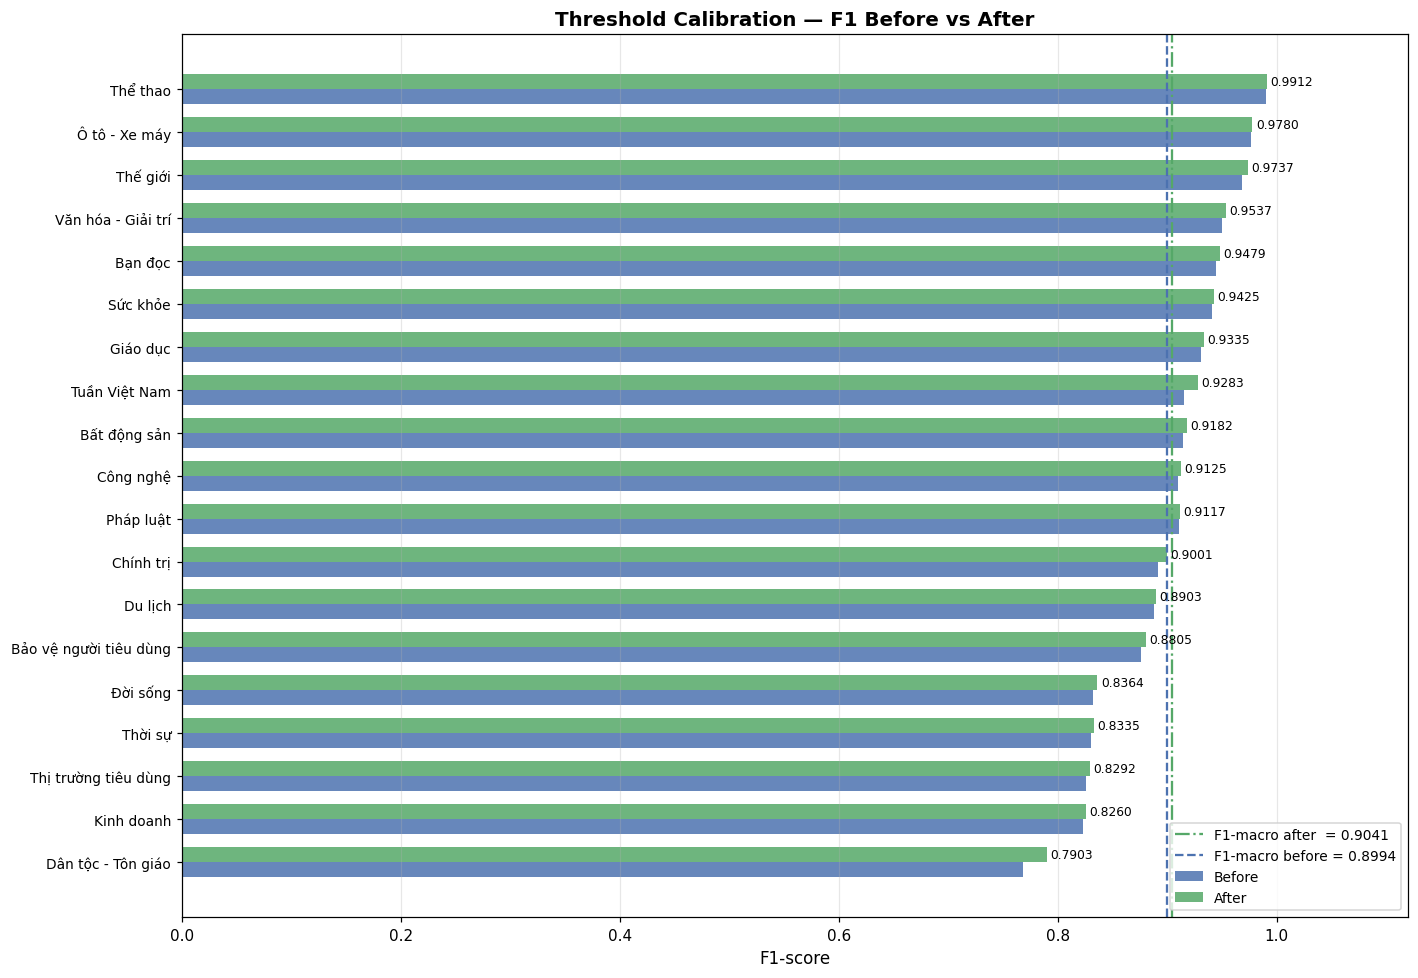

In [22]:
# ── 8.2 Visualize so sánh F1 before / after calibration ─────────────────────
_items_sorted = sorted(zip(classes, _base_f1, _cal_f1), key=lambda x: x[2])
_cls_names = [x[0] for x in _items_sorted]
_f1_before = [x[1] for x in _items_sorted]
_f1_after  = [x[2] for x in _items_sorted]

fig, ax = plt.subplots(figsize=(13, 9))
_y = np.arange(len(_cls_names))
_h = 0.35

_bars_b = ax.barh(_y - _h/2, _f1_before, _h, label="Before", color="#4C72B0", alpha=0.85)
_bars_a = ax.barh(_y + _h/2, _f1_after,  _h, label="After",  color="#55A868", alpha=0.85)

for bar, v in zip(_bars_a, _f1_after):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=8)

ax.set_yticks(_y); ax.set_yticklabels(_cls_names, fontsize=9)
ax.set_xlim(0, 1.12); ax.set_xlabel("F1-score", fontsize=11)
ax.axvline(cal_f1m,  color="#55A868", ls="-.", lw=1.5, label=f"F1-macro after  = {cal_f1m:.4f}")
ax.axvline(model_f1m, color="#4C72B0", ls="--",  lw=1.5, label=f"F1-macro before = {model_f1m:.4f}")
ax.set_title("Threshold Calibration — F1 Before vs After", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
save_fig(fig, "06_threshold_calibration.png")

In [23]:
# ── 8.3 Lưu thresholds vào model/ để app dùng ───────────────────────────────
_threshold_path = os.path.join(MODEL_DIR, "thresholds.json")

_threshold_config = {
    "temperature": T_OPTIMAL,
    "method":      "per_class_f1_grid_search",
    "search_range": [0.3, 3.5],
    "n_grid":      200,
    "n_passes":    3,
    "usage":       "predict = argmax(softmax(logits) / thresholds)",
    "thresholds":  {cls: float(thresholds[i]) for i, cls in enumerate(classes)},
    "metrics_before": {"accuracy": model_acc, "f1_weighted": model_f1w, "f1_macro": model_f1m},
    "metrics_after":  {"accuracy": cal_acc,   "f1_weighted": cal_f1w,   "f1_macro": cal_f1m},
}
with open(_threshold_path, "w", encoding="utf-8") as f:
    json.dump(_threshold_config, f, ensure_ascii=False, indent=2)
log(f"Thresholds saved: {_threshold_path}", "SAVE")

# Cập nhật label_config.json để app biết có threshold
with open(LABEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    _lc = json.load(f)
_lc["threshold_file"] = "thresholds.json"
_lc["use_threshold_calibration"] = True
with open(LABEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(_lc, f, ensure_ascii=False, indent=2)
log("label_config.json updated với threshold_file", "SAVE")

print(f"\n  [THRESHOLDS PER CLASS]")
print(f"  {'Class':<38}  {'Threshold':>10}  {'Ý nghĩa'}")
print(f"  {'─'*70}")
for i, cls in enumerate(classes):
    t = thresholds[i]
    if t > 1.2:   meaning = "Giảm over-prediction"
    elif t < 0.8: meaning = "Giảm under-prediction"
    else:         meaning = "Gần như không đổi"
    print(f"  {cls:<38}  {t:>10.4f}  {meaning}")

[07:57:33][16362.5s] >> Thresholds saved: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model\thresholds.json
[07:57:33][16362.5s] >> label_config.json updated với threshold_file

  [THRESHOLDS PER CLASS]
  Class                                    Threshold  Ý nghĩa
  ──────────────────────────────────────────────────────────────────────
  Bạn đọc                                     1.4739  Giảm over-prediction
  Bảo vệ người tiêu dùng                      1.0236  Gần như không đổi
  Bất động sản                                0.7663  Giảm under-prediction
  Chính trị                                   0.9432  Gần như không đổi
  Công nghệ                                   1.2648  Giảm over-prediction
  Du lịch                                     1.3774  Giảm over-prediction
  Dân tộc - Tôn giáo                          3.4196  Giảm over-prediction
  Giáo dục                                    2.7925  Giảm over-prediction
  Kinh doanh                               

---
## Section 9 - Diagnostic Print

Section nay chi print ra cac tin hieu can xem de cai thien model sau train va calibration, khong fine-tune them.


In [24]:
# -- 9.1 Build before/after diagnostic table ----------------------------------
if "_cal_preds" not in dir():
    probs = sp_softmax(raw_logits / T_OPTIMAL, axis=1)
    _cal_preds = np.argmax(probs / thresholds, axis=1)

_base_report = classification_report(
    y_true_ids, y_pred_ids, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_cal_report = classification_report(
    y_true_ids, _cal_preds, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_diag_df = pd.DataFrame([
    {
        "class": cls,
        "support": int(_base_report[cls]["support"]),
        "precision_before": _base_report[cls]["precision"],
        "recall_before":    _base_report[cls]["recall"],
        "f1_before":        _base_report[cls]["f1-score"],
        "precision_after":  _cal_report[cls]["precision"],
        "recall_after":     _cal_report[cls]["recall"],
        "f1_after":         _cal_report[cls]["f1-score"],
        "threshold":        float(thresholds[classes.index(cls)]),
    }
    for cls in classes
])
_diag_df["delta_f1"] = _diag_df["f1_after"] - _diag_df["f1_before"]
_diag_df["pr_gap_after"] = _diag_df["recall_after"] - _diag_df["precision_after"]
_diag_df["support_pct"] = _diag_df["support"] / max(int(_diag_df["support"].sum()), 1)

print(f"\n{'='*92}")
print("[PHOBERT DIAGNOSTIC SUMMARY]")
print(f"  F1-macro before : {model_f1m:.4f}")
print(f"  F1-macro after  : {cal_f1m:.4f}  ({cal_f1m - model_f1m:+.4f})")
print(f"  F1-weighted bef.: {model_f1w:.4f}")
print(f"  F1-weighted aft.: {cal_f1w:.4f}  ({cal_f1w - model_f1w:+.4f})")
print(f"  Accuracy before : {model_acc:.4f}")
print(f"  Accuracy after  : {cal_acc:.4f}  ({cal_acc - model_acc:+.4f})")
print(f"  Temperature     : {T_OPTIMAL:.4f}")
print(f"{'='*92}")

print("\n[5 WEAKEST CLASSES AFTER CALIBRATION]")
for _, r in _diag_df.sort_values(["f1_after", "support"], ascending=[True, True]).head(5).iterrows():
    print(f"  {r['class']:<30}  F1={r['f1_after']:.4f}  P={r['precision_after']:.4f}  R={r['recall_after']:.4f}  support={int(r['support'])}")

print("\n[5 SMALLEST CLASSES]")
for _, r in _diag_df.sort_values(["support", "f1_after"], ascending=[True, True]).head(5).iterrows():
    print(f"  {r['class']:<30}  support={int(r['support']):>5}  ({r['support_pct']*100:>5.2f}%)  F1_after={r['f1_after']:.4f}")

print("\n[5 MOST IMPROVED CLASSES AFTER CALIBRATION]")
for _, r in _diag_df.sort_values("delta_f1", ascending=False).head(5).iterrows():
    print(f"  {r['class']:<30}  before={r['f1_before']:.4f}  after={r['f1_after']:.4f}  delta={r['delta_f1']:+.4f}  thr={r['threshold']:.4f}")

print("\n[5 MOST DEGRADED CLASSES AFTER CALIBRATION]")
for _, r in _diag_df.sort_values("delta_f1", ascending=True).head(5).iterrows():
    print(f"  {r['class']:<30}  before={r['f1_before']:.4f}  after={r['f1_after']:.4f}  delta={r['delta_f1']:+.4f}  thr={r['threshold']:.4f}")

print("\n[CLASSES WITH LOW RECALL AFTER CALIBRATION]")
for _, r in _diag_df.sort_values("pr_gap_after", ascending=True).head(5).iterrows():
    print(f"  {r['class']:<30}  gap={r['pr_gap_after']:+.4f}  P={r['precision_after']:.4f}  R={r['recall_after']:.4f}  thr={r['threshold']:.4f}")

print("\n[CLASSES WITH LOW PRECISION AFTER CALIBRATION]")
for _, r in _diag_df.sort_values("pr_gap_after", ascending=False).head(5).iterrows():
    print(f"  {r['class']:<30}  gap={r['pr_gap_after']:+.4f}  P={r['precision_after']:.4f}  R={r['recall_after']:.4f}  thr={r['threshold']:.4f}")

# -- 9.2 Top confusion pairs after calibration -------------------------------
_cm_cal = confusion_matrix(y_true_ids, _cal_preds, labels=list(range(N_CLASSES)))
_pairs = []
for i, true_cls in enumerate(classes):
    _support = max(int(_cm_cal[i].sum()), 1)
    for j, pred_cls in enumerate(classes):
        if i == j or _cm_cal[i, j] == 0:
            continue
        _pairs.append({
            "count": int(_cm_cal[i, j]),
            "rate":  float(_cm_cal[i, j] / _support),
            "true":  true_cls,
            "pred":  pred_cls,
        })
_pairs_df = pd.DataFrame(_pairs).sort_values(["count", "rate"], ascending=[False, False]) if _pairs else pd.DataFrame(columns=["count", "rate", "true", "pred"])

print("\n[TOP 8 CONFUSION PAIRS AFTER CALIBRATION]")
if len(_pairs_df) == 0:
    print("  No off-diagonal confusion pairs.")
else:
    for _, r in _pairs_df.head(8).iterrows():
        print(f"  {r['true']:<28} -> {r['pred']:<28}  {int(r['count']):>4} times  ({r['rate']*100:>5.2f}%)")

# -- 9.3 Next-step hints -----------------------------------------------------
print("\n[PHOBERT NEXT-STEP HINTS]")
if (cal_f1w - cal_f1m) > 0.06:
    print("  - Weighted is still much higher than macro -> class imbalance is still visible; prioritize low-support and specialized classes.")
else:
    print("  - Weighted vs macro is already fairly close -> focus on the strongest confusion pairs.")

_thr_high = _diag_df[_diag_df["threshold"] > 1.4].sort_values("threshold", ascending=False)["class"].tolist()
_thr_low = _diag_df[_diag_df["threshold"] < 0.8].sort_values("threshold")["class"].tolist()
_low_f1 = _diag_df[_diag_df["f1_after"] < 0.80].sort_values("f1_after")["class"].tolist()

if _thr_high:
    print(f"  - High-threshold classes: {', '.join(_thr_high[:6])}{' ...' if len(_thr_high) > 6 else ''}")
    print("    Check whether these classes are truly over-predicted; if recall drops too much, lower threshold or add more data.")
if _thr_low:
    print(f"  - Low-threshold classes: {', '.join(_thr_low[:6])}{' ...' if len(_thr_low) > 6 else ''}")
    print("    If precision is still low here, calibration only treats the symptom; review data, class weight, and confusion pairs.")
if _low_f1:
    print(f"  - Classes with F1_after < 0.80: {', '.join(_low_f1[:6])}{' ...' if len(_low_f1) > 6 else ''}")
    print("    Prioritize real new samples, label review, or conservative class-boost adjustment for these classes.")

print("  - If a class improves mainly because of threshold tuning, the base model features may still be weak; do not rely on calibration alone long-term.")
print("  - If the same confusion pairs repeat, inspect real texts from those exact pairs; data fixes are often more effective than broad hyperparameter tuning.")
print("  - If macro F1 is still low after calibration, keep LR/epoch and try the next round with careful class boost, sampling, or more rare-class data.")



[PHOBERT DIAGNOSTIC SUMMARY]
  F1-macro before : 0.8994
  F1-macro after  : 0.9041  (+0.0046)
  F1-weighted bef.: 0.9071
  F1-weighted aft.: 0.9110  (+0.0039)
  Accuracy before : 0.9070
  Accuracy after  : 0.9109  (+0.0040)
  Temperature     : 1.2408

[5 WEAKEST CLASSES AFTER CALIBRATION]
  Dân tộc - Tôn giáo              F1=0.7903  P=0.7723  R=0.8091  support=503
  Kinh doanh                      F1=0.8260  P=0.8389  R=0.8134  support=1876
  Thị trường tiêu dùng            F1=0.8292  P=0.8386  R=0.8200  support=1400
  Thời sự                         F1=0.8335  P=0.8306  R=0.8364  support=1876
  Đời sống                        F1=0.8364  P=0.8281  R=0.8449  support=1876

[5 SMALLEST CLASSES]
  Dân tộc - Tôn giáo              support=  503  ( 1.57%)  F1_after=0.7903
  Bảo vệ người tiêu dùng          support=  581  ( 1.81%)  F1_after=0.8805
  Thị trường tiêu dùng            support= 1400  ( 4.36%)  F1_after=0.8292
  Du lịch                         support= 1602  ( 4.99%)  F1_after=0.890